#Take Home Assessment Overview
##Data Overview
*   orders.csv
    *   Purchase data for some of Extend’s merchants.
        * Check it out at a merchant like August to get a sense of the data.
* orderlines.csv
    * Individual line items purchased within an order.
* contracts.csv
    * Each warranty contract purchased by a consumer.
* merchants.csv
    * Data on each merchant that has integrated Extend’s purchase protection product.
* Data dictionary

##Questions w/ Answers
1. Please review the integrity of the data. Do you notice any data anomalies or
idiosyncrasies? If so, please describe them.
    
    **A:**  
    * In orders, source_name has 6 different app_id values for 'web'. Also, several records populate source_name with the numeric app_id rather than a descriptive source label. This affects our ability to accurately segment by source.
        * I imputed numeric values with 'unknown' except 580111 which matched 79K web app_id. 1354745 had matches in both shopify draft order and web. Since there was not enough evidence to support imputing either case, I also kept this as unknown.
    * There were about 7K missing is_warrantable records. After exploring these records, there was not enough evidence to support imputing with False or True.
        * Since this directly impacts attach rate analysis, I kept these records as null and calculated attach rate using only products marked as is_warrantable=True.
    * Orders and Order_lines had extreme outliers and results with zero price/discount. The extreme outliers are connected all to a luxury watch store so these are accurate. The zero price/discount results appear consistent with valid orders. There is no need to remove these from analysis.
    * I identified multiple contracts associated with the same line item_id. Most of these are legitimate because order lines contain multiple units. A subset had more contracts than purchased units.
        * I identified contracts identical across all columns with different contract ids. I removed the excess records from the subset with more contracts than purchased units.
    * All orders for the 3 RefurbPCLand results are attributed to the non-approved sortkey created in March 2020. This indicates merchant status is not aligned with transaction activity.
        * I treated the transactional sortkey as the source of truth for order and contract analysis and didn't use approved as a filter.
    * Contracts has products where the warranty was sold but in orderlines, it is marked as not warrantable.
        * I calculated attach rate by joining contracts and orderlines and taking the is_warrantable value count from there.


2. Calculate attach rate overall and by merchant per month on a unit and dollar basis.

    **A:**  
    * **Overall Unit Attach Rate:** 7.18%
    * **Overall Dollar Attach Rate:** 0.93%
    * **Overall Unit Attach Rate by Month:**
        * Mar 2020: 9.09%
        * Apr 2020: 8.22%
        * May 2020: 6.34%
    * **Overall Dollar Attach Rate by Month:**
        * Mar 2020: 1.34%
        * Apr 2020: 0.97%
        * May 2020: 0.84%

    * **Top 3 Unit Attach Rate by Merchant:**
        * ElectricSkatePark: 17.68%
        * RefurbPCLand: 15.13%
        * SecurityCamDirect: 14.29%
    * **Top 3 Dollar Attach Rate by Merchant:**
        * ElectricSkatePark: 2.81%
        * SecurityCamDirect: 2.71%
        * RefurbPCLand: 2.22%
    * **Top Unit Attach Rate by Merchant by Month:**
        * March 2020: SecurityCamDirect, 17.61%
        * April 2020: RefurbPCLand, 42.68%
        * May 2020: ElectricSkatePark, 20.00%
    * **Top Dollar Attach Rate by Merchant by Month:**
        * March 2020: SecurityCamDirect, 3.06%
        * April 2020: RefurbPCLand, 6.40%
        * May 2020: ElectricSkatePark, 3.16%

3. Which merchant industry would you focus business development on based on current attach rate and your views on market sizing?

        Assume we have roughly the same market penetration in each industry so that saturation is not a concern and assume net revenue to Extend is calculated by warranty sales * (1-merchant cut).
        Please put together a 2 or 3 page PowerPoint (or Google Slides) presentation to the Extend executive team with your recommendation.

    **A:**
    
    I would recommend focusing business development in the Sports & Fitness Equipment industry. It has the strongest market fit for warrant attachment and Extend revenue. It leads all industries in attach rate for both unit (9.57%) and dollar (1.52%) values and more than $65K in observed net revenue, exceeding other industries by more than 3x. The Sports & Fitness market is very large at about 58B in the US and expected to grow over time.  

4. After exploring the data, define at least two questions you would be interested in
exploring. Include 1 additional slide at the end of your PowerPoint presentation as “Next
Steps” and at a minimum, supply:

        a. What the question is and why it matters for the business.
        b. What in the current data you have assembled makes you interested in the question.
        c. What additional data would you want to explore the question.
        d. At a high level, what you would do with the data to answer the question.

    **A:**  
    **1. What is drving the overall decline in attach rate?**
    
    Why it matters:
    
    Unit attach rate decreases over the 3 month period from 9.09% to 6.34%. Dollar attach rate decreases from 1.34% to 0.84% in the same period. Understanding and fixing the decline would be a huge revenue oppotunity for Extend.

    What additional data is needed:
    
    I would want to determine whether the decline is due to merchant/product mix or declining performance within existing merchants. I would explore offer impressions, product attributes, merchant onboarding dates, checkout placement, and device. This would give a better view of what is driving warranty purchases.
    
    What would I do with the data:
    
    I would segment by these dimensions to specify why the decline is occuring. This would allow us to design A/B tests or regression experiments to determine whether changes can improve attachment.

    **2. What explains the large differences in attach rate among merchants in the same industry?**
    
    Why it matters:
    
    The Consumer Electronics industry ranges from 3.7% to 15.1% attach rate and Sports & Fitness Equipment ranges from 6.5% to 17.7%. Merchants in these industries are finding success while others are lagging behind. I would want to identify the merchant or product factors that explain why some merchants are outperforming others in the same industry.

    What additional data is needed:
    
    I would explore product category, warranty to product price ratio, offer placement, and device/channel.
    
    What would I do with the data:
    
    I'd perform segmented analysis and regression to quantify attach rate drivers for the high performing merchant/product combinations. Then I would design targeted A/B tests to evaluate if those strategies can be replicated for under performing merchants.

5. Please send a Jupyter/Rstudio notebook with your work and the files you utilized for
completing the exercise.


6. Please share any feedback you have on the exercise and how we can make it better!

    **A:**
    *  In the data overview it says "Check it out at a merchant like August to get a sense of the data." but there is no merchant named August.
    * Data dictionary doesn't include app_id or source_name in the orders table

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

#Load Data

In [2]:
#Load csvs to df
orders = pd.read_csv('orders.csv')
orderlines = pd.read_csv('order_lines.csv')
contracts = pd.read_csv('contracts.csv')
merchants = pd.read_csv('merchants.csv')

In [3]:
orders.head()

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
0,2084411998340,580111,web,2020-03-23 04:27:01+00,66.00,66.00,0.0,NaN,a5e80a29-c6af-446f-b569-f021e697c48c
1,2180040425590,580111,web,2020-05-02 15:25:35+00,251.99,251.99,0.0,United States,661964ec-5d06-4dea-bbb2-56d3b9817a98
2,2185892200566,580111,web,2020-05-04 19:41:09+00,197.33,183.99,46.0,United States,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd
3,2033752277015,580111,web,2020-04-15 23:54:26+00,150.00,150.00,0.0,United States,0d92cbe4-2d26-4c81-ae4e-7ace36b6700b
4,2212085137482,1354745,web,2020-03-09 17:01:24+00,2850.00,2850.00,400.0,Canada,d2d139d8-f36d-4183-bc9d-61353623036c


In [4]:
orderlines.head()

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
0,4730634797174,2141983408246,3.131829e+13,1,25.0,25.0,0.0,False,False
1,4841816752246,2194646532214,3.109589e+13,1,229.0,229.0,0.0,True,False
2,4830647713910,2189327073398,3.109589e+13,3,229.0,229.0,0.0,True,False
3,4818776522870,2183841480822,3.109589e+13,1,229.0,229.0,0.0,True,False
4,4816728326262,2183031095414,3.109589e+13,2,229.0,229.0,0.0,True,False


In [5]:
contracts.head()

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
0,001a6812-809e-4318-873d-4124742b7b69,30143018631191,0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,10001-misc-elec-base-replace-1y,2020-05-07 19:26:23.000000,23.99,False,1.0,4.507782e+12
1,01f5a99c-2a60-4080-950d-3607699c07c9,31095887003766,661964ec-5d06-4dea-bbb2-56d3b9817a98,10001-misc-elec-base-replace-1y,2020-05-06 00:48:11.000000,22.99,False,1.0,4.830406e+12
2,01836ce1-283e-4979-a1c1-b6e876b9ab34,31437319733291,fb650744-0bf1-4662-a98c-b7a35f5f540f,10001-laptop-base-replace-2y,2020-03-24 17:24:38.000000,31.99,False,2.0,4.414598e+12
3,03014a1f-212e-40d0-a0cb-fed261956c7b,31436843843627,fb650744-0bf1-4662-a98c-b7a35f5f540f,10001-laptop-base-replace-2y,2020-03-16 19:08:05.000000,35.99,False,2.0,4.398919e+12
4,03299045-7778-40af-91af-9f9013a1cecb,29266134663242,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,10001-misc-elec-base-replace-3y,2020-05-26 22:12:55.000000,59.99,False,3.0,5.351137e+12


In [6]:
merchants.head()

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
0,STORE::fd8f6538-a246-4fc8-b179-ca40fccfbb25,PowerMassagerPros,2019-08-13 23:00:31.000000,True,True,0.25,Sports & Fitness Equipment
1,STORE::780a27f2-578d-4455-818f-77b48453ffb9,ElectricSkatePark,2020-02-15 18:46:36.837000,True,True,0.20,Sports & Fitness Equipment
2,STORE::661964ec-5d06-4dea-bbb2-56d3b9817a98,FitnessWareables,2019-11-18 20:36:57.000000,True,True,0.30,Sports & Fitness Equipment
3,STORE::2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,HomeSecurityMart,2019-09-25 19:57:26.000000,True,True,0.25,Home Security
4,STORE::2399c6c4-23d6-4d10-8810-b294c8cb3359,SkateboardsUSA,2019-11-13 17:04:30.000000,True,True,0.30,Sports & Fitness Equipment


#Data Overview & Cleaning

## Orders


In [7]:
orders.shape

(81943, 9)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81943 entries, 0 to 81942
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          81943 non-null  int64  
 1   app_id            81943 non-null  int64  
 2   source_name       81943 non-null  object 
 3   ordered_at        81943 non-null  object 
 4   total_price       81943 non-null  float64
 5   subtotal_price    81943 non-null  float64
 6   total_discount    81943 non-null  float64
 7   shipping_country  81817 non-null  object 
 8   store_id          81943 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 5.6+ MB


In [9]:
orders.describe(include='all')

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
count,8.194300e+04,8.194300e+04,81943,81943,81943.000000,81943.000000,81943.000000,81817,81943
unique,NaN,NaN,18,81164,NaN,NaN,NaN,68,15
top,NaN,NaN,web,2020-05-03 19:48:25+00,NaN,NaN,NaN,United States,5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5
freq,NaN,NaN,79141,3,NaN,NaN,NaN,80199,21831
mean,2.226457e+12,6.077757e+05,NaN,NaN,420.261019,398.702319,24.427744,NaN,NaN
std,1.195963e+11,1.650209e+05,NaN,NaN,1357.791246,1286.156983,83.705853,NaN,NaN
min,1.985851e+12,8.831200e+04,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
25%,2.134873e+12,5.801110e+05,NaN,NaN,61.250000,56.555000,0.000000,NaN,NaN
50%,2.210969e+12,5.801110e+05,NaN,NaN,156.590000,143.990000,0.000000,NaN,NaN
75%,2.327572e+12,5.801110e+05,NaN,NaN,267.110000,249.990000,29.305000,NaN,NaN


### Key Notes - orders
* dtype of ordered at needs to be updated to datetime.
* ~100 null values in the shipping country column
* ~800 duplicate order times in the order at column. Since this goes by the second, it could indicate duplicates.
* Min order price is 0. Were these fully discounted orders? Or are these inaccurate values?
* Mean price for total and subtotal is far greater than the median price, suggesting our data could be skewed by outliers. The max order total is ~80 stds above the mean suggesting this could be inaccurate.

### Update dtypes

In [10]:
orders['ordered_at'] = pd.to_datetime(orders['ordered_at'])

In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81943 entries, 0 to 81942
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   order_id          81943 non-null  int64              
 1   app_id            81943 non-null  int64              
 2   source_name       81943 non-null  object             
 3   ordered_at        81943 non-null  datetime64[ns, UTC]
 4   total_price       81943 non-null  float64            
 5   subtotal_price    81943 non-null  float64            
 6   total_discount    81943 non-null  float64            
 7   shipping_country  81817 non-null  object             
 8   store_id          81943 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(3), int64(2), object(3)
memory usage: 5.6+ MB


This confirms the dtype was updated to datetime

### Investigate Null values

First I'll define a function to summarize missing values in the df

In [12]:
def missing_summary(df):
  """Returns a summary of missing values in a dataframe"""
  return (
        df.isna()
          .sum()
          .to_frame("missing_count")
          .assign(missing_pct=lambda x: x["missing_count"] / len(df))
          .sort_values("missing_pct", ascending=False)
    )

In [13]:
missing_summary(orders)

,missing_count,missing_pct
shipping_country,126,0.001538
order_id,0,0.000000
app_id,0,0.000000
ordered_at,0,0.000000
source_name,0,0.000000
total_price,0,0.000000
subtotal_price,0,0.000000
total_discount,0,0.000000
store_id,0,0.000000


In [14]:
orders['shipping_country'].value_counts()

,count
shipping_country,
United States,80199
Canada,1105
US,74
United Kingdom,61
Australia,56
...,...
CN,1
ES,1
Malta,1


We have some country values that are listing abbreviations instead of full names. We'll have to adjust this to make it consistent.

In [15]:
#get distinct country names
unique_countries = orders['shipping_country'].astype(str).unique()

#get country abbreviations
abbreviations = [country for country in unique_countries if len(country) <= 3 and country.isupper()]

print(abbreviations)

['US', 'HK', 'DE', 'FR', 'CH', 'CA', 'JP', 'PT', 'DK', 'MC', 'GB', 'IT', 'AT', 'AE', 'MY', 'NO', 'AU', 'SE', 'CN', 'ES']


In [16]:
country_mapping = {
    'US': 'United States',
    'UK': 'United Kingdom',
    'GB': 'United Kingdom', #Great Britain is often used for UK
    'CA': 'Canada',
    'AU': 'Australia',
    'DE': 'Germany',
    'FR': 'France',
    'JP': 'Japan',
    'CN': 'China',
    'ES': 'Spain',
    'IT': 'Italy',
    'CH': 'Switzerland',
    'PT': 'Portugal',
    'DK': 'Denmark',
    'MC': 'Monaco',
    'AE': 'United Arab Emirates',
    'MY': 'Malaysia',
    'NO': 'Norway',
    'SE': 'Sweden',
    'HK': 'Hong Kong',
    'AT': 'Austria'
}

#replace abbreviations with full names
orders['shipping_country'] = orders['shipping_country'].replace(country_mapping)

#standardize 'united states' to 'United States'
orders['shipping_country'] = orders['shipping_country'].replace('united states', 'United States')

#display updated value counts to verify changes
print("Updated 'shipping_country' value counts:")
orders['shipping_country'].value_counts()

Updated 'shipping_country' value counts:


,count
shipping_country,
United States,80284
Canada,1112
United Kingdom,63
Australia,57
France,29
Germany,27
Switzerland,26
Saudi Arabia,19
Mexico,14


In [17]:
orders[orders['shipping_country'].isna()].head(10)

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
0,2084411998340,580111,web,2020-03-23 04:27:01+00:00,66.00,66.00,0.0,NaN,a5e80a29-c6af-446f-b569-f021e697c48c
224,2186914201732,580111,web,2020-04-26 22:52:29+00:00,134.99,134.99,0.0,NaN,a5e80a29-c6af-446f-b569-f021e697c48c
551,2184095465526,580111,web,2020-05-29 01:07:59+00:00,0.00,0.00,0.0,NaN,fd8f6538-a246-4fc8-b179-ca40fccfbb25
1578,2277428035716,580111,web,2020-05-25 17:14:38+00:00,77.00,77.00,0.0,NaN,a5e80a29-c6af-446f-b569-f021e697c48c
2195,2156526272644,1195292,web,2020-04-17 17:50:27+00:00,38.33,35.99,0.0,NaN,a5e80a29-c6af-446f-b569-f021e697c48c
5696,2255694364808,580111,web,2020-05-04 02:55:18+00:00,100.00,100.00,0.0,NaN,2399c6c4-23d6-4d10-8810-b294c8cb3359
5905,2024834826283,2775929,2775929,2020-03-26 03:38:25+00:00,919.01,866.99,0.0,NaN,fb650744-0bf1-4662-a98c-b7a35f5f540f
6216,2217964994696,580111,web,2020-04-21 20:58:03+00:00,500.00,500.00,0.0,NaN,2399c6c4-23d6-4d10-8810-b294c8cb3359
6877,2031712469035,580111,web,2020-03-29 22:46:57+00:00,39.99,39.99,0.0,NaN,fb650744-0bf1-4662-a98c-b7a35f5f540f
7371,2150312181892,580111,web,2020-04-15 20:20:26+00:00,269.98,269.98,0.0,NaN,a5e80a29-c6af-446f-b569-f021e697c48c


The missing country values are a very low percentage of our overall results. At the outset, most of these look legitimate. Since there is no analytical benefit to imputing these and no evidence to decipher geography, we can just reassign the null values to unknown.

The only glaring discrepancy is that there are a few orders with source names identical to app ids and differing app ids for the same source (web)

In [18]:
#impute missing countries to unknown
orders['shipping_country'] = orders['shipping_country'].fillna('Unknown')

In [19]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81943 entries, 0 to 81942
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   order_id          81943 non-null  int64              
 1   app_id            81943 non-null  int64              
 2   source_name       81943 non-null  object             
 3   ordered_at        81943 non-null  datetime64[ns, UTC]
 4   total_price       81943 non-null  float64            
 5   subtotal_price    81943 non-null  float64            
 6   total_discount    81943 non-null  float64            
 7   shipping_country  81943 non-null  object             
 8   store_id          81943 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(3), int64(2), object(3)
memory usage: 5.6+ MB


In [20]:
#value counts for app_id & source name
orders[['app_id', 'source_name']].value_counts()

,,count
app_id,source_name,
580111,web,77649
1354745,web,1405
580111,580111,1254
1354745,shopify_draft_order,697
294517,294517,229
2376822,2376822,190
1197798,sell-on-amazon,166
1354745,1354745,103
1150484,web,83


In [21]:
#See where source_name and app_id are identical
orders[pd.to_numeric(orders['source_name'], errors='coerce') == orders['app_id']].head(10)

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
16,2174805049462,580111,580111,2020-04-30 19:56:10+00:00,229.00,229.00,0.00,United States,661964ec-5d06-4dea-bbb2-56d3b9817a98
34,2289228710001,580111,580111,2020-04-25 15:11:47+00:00,727.45,673.98,0.00,United States,5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5
53,2101321597064,1354745,1354745,2020-03-23 18:05:04+00:00,2434.91,2199.00,50.00,United States,2399c6c4-23d6-4d10-8810-b294c8cb3359
66,2138211450934,294517,294517,2020-05-06 13:06:57+00:00,32.34,25.00,0.00,United States,fd8f6538-a246-4fc8-b179-ca40fccfbb25
69,2130716524601,2376822,2376822,2020-05-28 18:59:53+00:00,0.00,0.00,1199.99,United States,2e1df809-4f73-4943-9bde-49fdbeddb8fc
161,2108436578365,1156738,1156738,2020-05-21 17:20:33+00:00,652.65,609.95,0.00,United States,cbd9a3a0-8457-4bd9-abf6-5de6b62da6c2
191,2219982356598,580111,580111,2020-05-17 19:17:32+00:00,21.06,20.00,0.00,United States,661964ec-5d06-4dea-bbb2-56d3b9817a98
259,2347231772785,580111,580111,2020-05-12 00:18:51+00:00,62.78,47.96,0.00,United States,5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5
287,2208157237350,294517,294517,2020-05-05 01:02:02+00:00,64.59,64.59,0.00,United States,c18e4014-49ee-4f3d-8813-c7a9f2e407b9
308,2159885484150,580111,580111,2020-04-24 21:14:33+00:00,267.05,249.00,0.00,United States,661964ec-5d06-4dea-bbb2-56d3b9817a98


580111 matches 79K web records so we can impute these results to web. 1354745 matches web, shopify_draft_order, and its own numeric value. Since this is such a small percentage of the data, I'll leave these as is. The others don't match any other descriptive value. I'll impute these with 'Unknown'.

In [22]:
#impute matching web numerical values
orders.loc[orders['source_name'].astype(str).isin(['580111', '88312']), 'source_name'] = 'web'

In [23]:
#impute all other numerical values to 'unknown' source name
orders.loc[
    orders["source_name"].astype(str).str.fullmatch(r"\d+"),
    "source_name"
] = "unknown"

In [24]:
#verify data was imputed
orders[['app_id', 'source_name']].value_counts()

app_id   source_name        
580111   web                    78903
1354745  web                     1405
         shopify_draft_order      697
294517   unknown                  229
2376822  unknown                  190
1197798  sell-on-amazon           166
1354745  unknown                  103
1150484  web                       83
2331682  unknown                   48
188777   Edit Order                36
1156738  unknown                   26
1775805  unknown                   18
352363   Returnly Exchanges         9
1424624  unknown                    8
2615327  Google via Ueblo           7
2775929  unknown                    5
118385   iphone                     4
88312    web                        3
166357   android                    1
273625   web                        1
1195292  web                        1
Name: count, dtype: int64

### Investigate duplicate order times

In [25]:
#investigate repeated times
dup_times = orders[
    orders["ordered_at"].duplicated(keep=False)
].sort_values("ordered_at")

dup_times.head(20)

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
13787,2027107549238,580111,web,2020-03-02 02:52:07+00:00,249.99,249.99,0.00,United States,fd8f6538-a246-4fc8-b179-ca40fccfbb25
49590,2002147016761,580111,web,2020-03-02 02:52:07+00:00,412.37,385.40,84.59,United States,2e1df809-4f73-4943-9bde-49fdbeddb8fc
41682,2195904528458,580111,web,2020-03-02 18:20:05+00:00,37.47,34.94,0.00,United States,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b
49215,2027807211652,580111,web,2020-03-02 18:20:05+00:00,155.93,149.98,10.00,United States,a5e80a29-c6af-446f-b569-f021e697c48c
79435,2198822846538,1354745,web,2020-03-03 15:41:43+00:00,8078.50,7550.00,300.00,United States,d2d139d8-f36d-4183-bc9d-61353623036c
43577,2029013762180,580111,web,2020-03-03 15:41:43+00:00,79.99,79.99,10.00,United States,a5e80a29-c6af-446f-b569-f021e697c48c
61841,2034261622915,580111,web,2020-03-04 18:16:40+00:00,0.00,0.00,80.97,United States,446af1d1-22e5-41cb-bbb1-dc6e7ad970b4
7964,2060240879734,580111,web,2020-03-04 18:16:40+00:00,167.90,152.99,27.00,United States,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd
72305,2044825763976,580111,web,2020-03-07 23:13:04+00:00,215.46,199.99,0.00,United States,2399c6c4-23d6-4d10-8810-b294c8cb3359
12793,2034417434678,580111,web,2020-03-07 23:13:04+00:00,499.99,499.99,0.00,United States,fd8f6538-a246-4fc8-b179-ca40fccfbb25


In [26]:
#check for full matches
orders[
    orders.duplicated(
        subset=[
            "ordered_at",
            "total_price",
            "subtotal_price",
            "total_discount",
            "shipping_country",
            "store_id",
        ],
        keep=False
    )
].sort_values("ordered_at")

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
24580,2190888697974,580111,web,2020-05-06 18:05:46+00:00,154.07,143.99,36.0,United States,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd
38422,2190888730742,580111,web,2020-05-06 18:05:46+00:00,154.07,143.99,36.0,United States,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd
8591,2395814494282,580111,web,2020-05-12 17:43:19+00:00,257.48,249.99,0.0,United States,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b
37958,2395814527050,580111,web,2020-05-12 17:43:19+00:00,257.48,249.99,0.0,United States,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b
47995,2396280291402,580111,web,2020-05-12 20:03:11+00:00,249.99,249.99,0.0,United States,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b
55421,2396280389706,580111,web,2020-05-12 20:03:11+00:00,249.99,249.99,0.0,United States,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b


These orders were placed at the same stores at the same exact second for the
same price. There is not enough evidence to warrant removing these so we will keep them in the analysis. It is plausible in ecommerce that multiple orders could be place at the same time for the same products.

### Investigate  outliers

First I'll explore the cases where total price is 0 and discount is 0 to ensure these are accurate

In [27]:
#get zero price orders
zero_price_orders = orders[(orders['total_price'] == 0) & (orders['total_discount'] == 0)]

zero_price_orders.shape

(140, 9)

In [28]:
#see where matching zero price lines
zero_price_lines = orderlines[
    orderlines["order_id"].isin(zero_price_orders["order_id"])
]

zero_price_lines[
    ["order_id", "line_item_id", "quantity", "price",
     "product_purchase_price", "discount_per_item",
     "is_warrantable", "is_warranty"]
].sort_values("order_id")

,order_id,line_item_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
102848,2097988239414,4607092293686,1,0.0,0.0,0.0,False,False
92349,2113533214851,4661124235395,1,0.0,0.0,0.0,NaN,False
85529,2149490622518,4704095502390,1,0.0,0.0,0.0,False,False
87623,2162890866824,4692289519752,1,0.0,0.0,0.0,False,False
132643,2164604665958,4739531210854,1,0.0,0.0,0.0,False,False
...,...,...,...,...,...,...,...,...
20007,2391015161969,5101100859505,1,0.0,0.0,0.0,NaN,False
24805,2396860940401,5111879336049,1,0.0,0.0,0.0,NaN,False
26954,2400081051761,5117067165809,1,0.0,0.0,0.0,NaN,False
112234,2410563829873,5134454390897,1,0.0,0.0,0.0,NaN,False


In [29]:
zero_price_lines[
    ["order_id", "line_item_id", "quantity", "price",
     "product_purchase_price", "discount_per_item",
     "is_warrantable", "is_warranty"]
].sort_values("order_id").describe(include='all')

,order_id,line_item_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
count,2.030000e+02,2.030000e+02,203.000000,203.0,203.0,203.0,93,203
unique,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,93,203
mean,2.259010e+12,4.904547e+12,1.019704,0.0,0.0,0.0,NaN,NaN
std,6.301298e+10,9.640857e+10,0.139326,0.0,0.0,0.0,NaN,NaN
min,2.097988e+12,4.607092e+12,1.000000,0.0,0.0,0.0,NaN,NaN
25%,2.222238e+12,4.852649e+12,1.000000,0.0,0.0,0.0,NaN,NaN
50%,2.243830e+12,4.895179e+12,1.000000,0.0,0.0,0.0,NaN,NaN
75%,2.289975e+12,4.961616e+12,1.000000,0.0,0.0,0.0,NaN,NaN


These results appear to be consistent with valid orders so we will keep these for analysis. All of these aren't warrantable and don't have a warranty. About half of these results have null values in is_warrantable.

In [30]:
#pull highest priced orders
highest_price_orders = orders.nlargest(20, "total_price")[
    ["order_id", "store_id", "ordered_at", "total_price"]
]
highest_price_orders

,order_id,store_id,ordered_at,total_price
5654,2445945307210,d2d139d8-f36d-4183-bc9d-61353623036c,2020-05-27 14:32:05+00:00,112035.87
63861,2201488883786,d2d139d8-f36d-4183-bc9d-61353623036c,2020-03-04 19:33:10+00:00,78553.31
358,2223941058634,d2d139d8-f36d-4183-bc9d-61353623036c,2020-03-15 16:45:28+00:00,71692.50
79188,2396200239178,d2d139d8-f36d-4183-bc9d-61353623036c,2020-05-12 19:39:08+00:00,44220.20
29078,2199218487370,d2d139d8-f36d-4183-bc9d-61353623036c,2020-03-03 19:06:50+00:00,44000.00
66664,2379520671818,d2d139d8-f36d-4183-bc9d-61353623036c,2020-05-07 19:42:30+00:00,39288.20
72880,2374794838090,d2d139d8-f36d-4183-bc9d-61353623036c,2020-05-06 15:11:03+00:00,35535.00
34387,2280075558986,d2d139d8-f36d-4183-bc9d-61353623036c,2020-04-08 11:50:55+00:00,32380.00
30084,2446588280906,d2d139d8-f36d-4183-bc9d-61353623036c,2020-05-27 18:21:42+00:00,31925.00
21989,2410923524170,d2d139d8-f36d-4183-bc9d-61353623036c,2020-05-16 22:28:01+00:00,30329.06


It appears that one merchant is responsible for all the highest sales. This gives us more confidence the results are accurate as this store sells higher priced items.

In [31]:
#check merchant matching high priced records
merchants[merchants['sortkey'] == 'STORE::d2d139d8-f36d-4183-bc9d-61353623036c']

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
15,STORE::d2d139d8-f36d-4183-bc9d-61353623036c,LuxuryWatchDepot,2019-10-17 01:00:40.000000,True,True,0.35,Watches & Jewelry


This is a luxury watch store. It makes sense to have such high prices for individual items.

##Orderlines

In [32]:
orderlines.shape

(147041, 9)

In [33]:
orderlines.head()

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
0,4730634797174,2141983408246,3.131829e+13,1,25.0,25.0,0.0,False,False
1,4841816752246,2194646532214,3.109589e+13,1,229.0,229.0,0.0,True,False
2,4830647713910,2189327073398,3.109589e+13,3,229.0,229.0,0.0,True,False
3,4818776522870,2183841480822,3.109589e+13,1,229.0,229.0,0.0,True,False
4,4816728326262,2183031095414,3.109589e+13,2,229.0,229.0,0.0,True,False


In [34]:
orderlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147041 entries, 0 to 147040
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   line_item_id            147041 non-null  int64  
 1   order_id                147041 non-null  int64  
 2   variant_id              144462 non-null  float64
 3   quantity                147041 non-null  int64  
 4   price                   147041 non-null  float64
 5   product_purchase_price  147041 non-null  float64
 6   discount_per_item       147041 non-null  float64
 7   is_warrantable          139889 non-null  object 
 8   is_warranty             147041 non-null  bool   
dtypes: bool(1), float64(4), int64(3), object(1)
memory usage: 9.1+ MB


In [35]:
orderlines.describe(include='all')

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
count,1.470410e+05,1.470410e+05,1.444620e+05,147041.000000,147041.000000,147041.000000,147041.000000,139889,147041
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85559,142677
mean,4.882726e+12,2.253552e+12,2.057518e+13,1.481015,222.861717,218.806005,4.055711,NaN,NaN
std,2.158832e+11,1.181177e+11,1.186585e+13,3.005043,949.639827,948.411981,19.411081,NaN,NaN
min,4.360123e+12,1.985851e+12,4.547400e+08,1.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,4.768095e+12,2.170118e+12,1.224803e+13,1.000000,6.990000,6.990000,0.000000,NaN,NaN
50%,4.927517e+12,2.283066e+12,2.906641e+13,1.000000,30.000000,30.000000,0.000000,NaN,NaN
75%,5.037655e+12,2.354034e+12,3.121116e+13,1.000000,179.990000,159.990000,0.000000,NaN,NaN


### Key Notes - orderlines

*   ~2500 null values from variant id. These could indicate illegitimate orders because this column indicates the unique product.
*   ~7000 null values for is_warrantable. Should these be treated as False? False is the majority (61%)
* is_warrantable should be bool dtype instead of object, needs to be updated
* Similar to orders, quantity has a max of 500 and price has a max of 72150. These are many stds above the mean and could be indicative of inaccurate results
* Min order price is also 0 here indicating fully discounted orders or inaccurate results




###Investigate null values

In [36]:
missing_summary(orderlines)

,missing_count,missing_pct
is_warrantable,7152,0.048639
variant_id,2579,0.017539
line_item_id,0,0.000000
quantity,0,0.000000
order_id,0,0.000000
price,0,0.000000
product_purchase_price,0,0.000000
discount_per_item,0,0.000000
is_warranty,0,0.000000


In [37]:
orderlines[orderlines['variant_id'].isna()].head(10)

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
15464,4995763077233,2333253206129,NaN,1,399.99,399.99,0.0,NaN,False
15476,5117454188657,2400331006065,NaN,1,1.80,1.80,0.0,NaN,False
15768,5078364487793,2381928300657,NaN,1,2.00,2.00,0.0,NaN,False
15781,5070177108081,2376602517617,NaN,1,1.09,1.09,0.0,NaN,False
15783,5080053284977,2382875295857,NaN,1,4.11,4.11,0.0,NaN,False
15787,5106192384113,2393623756913,NaN,1,4.31,4.31,0.0,NaN,False
15790,5071295938673,2377304998001,NaN,1,0.61,0.61,0.0,NaN,False
15793,5068040568945,2375171113073,NaN,1,3.89,3.89,0.0,NaN,False
15794,5079961239665,2382837383281,NaN,1,3.00,3.00,0.0,NaN,False
15888,4518316474425,2073263439929,NaN,1,23.50,23.50,0.0,NaN,False


In [38]:
orderlines[orderlines['variant_id'].isna()].describe(include='all')

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
count,2.579000e+03,2.579000e+03,0.0,2579.000000,2579.000000,2579.000000,2579.000000,138,2579
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138,2579
mean,5.035383e+12,2.355081e+12,NaN,1.043428,24.251373,24.000825,0.250547,NaN,NaN
std,1.629637e+11,8.993227e+10,NaN,0.504109,137.930024,136.875644,7.524202,NaN,NaN
min,4.367178e+12,1.991269e+12,NaN,1.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,5.050022e+12,2.364033e+12,NaN,1.000000,1.200000,1.200000,0.000000,NaN,NaN
50%,5.076838e+12,2.381012e+12,NaN,1.000000,2.730000,2.730000,0.000000,NaN,NaN
75%,5.117012e+12,2.400042e+12,NaN,1.000000,5.690000,5.675000,0.000000,NaN,NaN


We can keep these values as null as there is nothing to suggest anything would be inaccurate with a missing variant_id.

Since is_warrantable will directly impact our attach rate analysis, I will investigate this deeply

In [39]:
#examine null is_warrantable by price
orderlines.groupby(
    orderlines["is_warrantable"].isna()
).agg(
    rows=("line_item_id", "size"),
    avg_price=("product_purchase_price", "mean"),
    zero_price_pct=("product_purchase_price", lambda x: (x == 0).mean())
)

,rows,avg_price,zero_price_pct
is_warrantable,,,
False,139889,227.488926,0.004475
True,7152,48.973079,0.016359


The missing is_warrantable values have a much lower average price. Only 1.6% have zero price compared to the 0.4% zero price rate for values with is_warrantable.

In [40]:
#missing is_warrantable fields
missing_warrantable = orderlines[
    orderlines["is_warrantable"].isna()
]

#checking matching contracts for missing values
contracts[
    contracts["line_item_id"].isin(
        missing_warrantable["line_item_id"]
    )
].shape

(0, 9)

Since this is empty, it could indicate that missing records behave like non-warrantable values but I would need more evidence to conclude that.

In [41]:
#invesigate missing records by store
missing_by_store = (
    orderlines
    .merge(
        orders[["order_id", "store_id"]],
        on="order_id",
        how="left"
    )
    .groupby("store_id")
    .agg(
        total_lines=("line_item_id", "size"),
        missing_warrantable=(
            "is_warrantable",
            lambda x: x.isna().sum()
        )
    )
)

#calculcate missing percentage
missing_by_store["missing_pct"] = (
    missing_by_store["missing_warrantable"] /
    missing_by_store["total_lines"]
)

#sort by missing percentage
missing_by_store.sort_values(
    "missing_pct",
    ascending=False
).head(10)

,total_lines,missing_warrantable,missing_pct
store_id,,,
fb650744-0bf1-4662-a98c-b7a35f5f540f,1300,153,0.117692
a5e80a29-c6af-446f-b569-f021e697c48c,4053,462,0.113990
780a27f2-578d-4455-818f-77b48453ffb9,362,39,0.107735
661964ec-5d06-4dea-bbb2-56d3b9817a98,10495,867,0.082611
0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,6508,534,0.082053
2e1df809-4f73-4943-9bde-49fdbeddb8fc,4637,348,0.075049
446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,4111,305,0.074191
cbd9a3a0-8457-4bd9-abf6-5de6b62da6c2,4633,279,0.060220
2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,8010,404,0.050437


Approximately 5% of order lines have null is_warrantable values, with some specific merchants reaching nearly 12%. None of these lines are associated with warranty contracts. Because the data does not establish whether null represents non-warrantable status, I retained the nulls and excluded them from the attach rate analysis. This may slightly overstate attach rate if some missing records were actually warrantable.

###Investigate outliers

In [42]:
#get zero price orderline results
zero_price_OL = orderlines[(orderlines['product_purchase_price'] == 0) & (orderlines['discount_per_item'] == 0)]

zero_price_OL.shape

(400, 9)

In [43]:
zero_price_OL.describe(include='all')

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty
count,4.000000e+02,4.000000e+02,2.580000e+02,400.000000,400.0,400.0,400.0,283,400
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283,400
mean,4.906117e+12,2.270334e+12,9.705885e+12,1.015000,0.0,0.0,0.0,NaN,NaN
std,1.236965e+11,7.555343e+10,7.849118e+12,0.121705,0.0,0.0,0.0,NaN,NaN
min,4.486992e+12,2.029136e+12,3.282924e+10,1.000000,0.0,0.0,0.0,NaN,NaN
25%,4.851927e+12,2.224201e+12,3.282924e+10,1.000000,0.0,0.0,0.0,NaN,NaN
50%,4.920057e+12,2.268130e+12,1.276172e+13,1.000000,0.0,0.0,0.0,NaN,NaN
75%,4.970386e+12,2.321115e+12,1.534518e+13,1.000000,0.0,0.0,0.0,NaN,NaN


Just like orders, these all look like legitimate zero-value, non-warranty items and not inaccurate prices. There is no evidence to support imputing these in any fashion.

In [44]:
#highest price orderline vlues
highest_price_OL = orderlines.nlargest(20, "product_purchase_price")[
    ["order_id", "line_item_id", "product_purchase_price"]
]
highest_price_OL

,order_id,line_item_id,product_purchase_price
81152,2201488883786,4816758571082,72150.0
74350,2223941058634,4865671626826,66000.0
34522,2445945307210,5355436933194,51900.0
32481,2445945307210,5355436900426,50900.0
36357,2396200239178,5247637880906,41795.0
31952,2379520671818,5210909868106,38000.0
82005,2374794838090,5200583032906,33500.0
74896,2280075558986,4991557730378,31000.0
46950,2406576291914,5269906030666,29900.0
30092,2410923524170,5278732582986,28720.0


In [45]:
#check where matches with high order values
highest_price_OL_orders = orders[
    orders["order_id"].isin(highest_price_OL["order_id"])
]

highest_price_OL_orders

,order_id,app_id,source_name,ordered_at,total_price,subtotal_price,total_discount,shipping_country,store_id
358,2223941058634,580111,web,2020-03-15 16:45:28+00:00,71692.50,66000.0,0.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
1850,2346814406730,580111,web,2020-04-29 02:01:50+00:00,27342.70,25795.0,0.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
5654,2445945307210,1354745,shopify_draft_order,2020-05-27 14:32:05+00:00,112035.87,102550.0,250.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
8676,2208670384202,580111,web,2020-03-07 22:03:36+00:00,24072.00,24072.0,0.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
13584,2329906282570,580111,web,2020-04-24 00:47:46+00:00,27640.23,25358.0,1000.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
16930,2396503638090,1354745,web,2020-05-12 21:19:04+00:00,26547.75,24300.0,700.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
20387,2274627813450,1354745,web,2020-04-06 08:43:39+00:00,27989.48,26358.0,0.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
21888,2360980078666,580111,web,2020-05-02 19:35:00+00:00,28151.71,26310.0,0.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
21989,2410923524170,580111,web,2020-05-16 22:28:01+00:00,30329.06,28545.0,175.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c
34387,2280075558986,580111,web,2020-04-08 11:50:55+00:00,32380.00,30500.0,500.0,United States,d2d139d8-f36d-4183-bc9d-61353623036c


All of the highest order line prices are in the highest orders. These all also stem from the Luxury Watch Depot so these are all accurate.

##Contracts

Now I'll explore the contracts table

In [46]:
contracts.shape

(4891, 9)

In [47]:
contracts.head()

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
0,001a6812-809e-4318-873d-4124742b7b69,30143018631191,0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,10001-misc-elec-base-replace-1y,2020-05-07 19:26:23.000000,23.99,False,1.0,4.507782e+12
1,01f5a99c-2a60-4080-950d-3607699c07c9,31095887003766,661964ec-5d06-4dea-bbb2-56d3b9817a98,10001-misc-elec-base-replace-1y,2020-05-06 00:48:11.000000,22.99,False,1.0,4.830406e+12
2,01836ce1-283e-4979-a1c1-b6e876b9ab34,31437319733291,fb650744-0bf1-4662-a98c-b7a35f5f540f,10001-laptop-base-replace-2y,2020-03-24 17:24:38.000000,31.99,False,2.0,4.414598e+12
3,03014a1f-212e-40d0-a0cb-fed261956c7b,31436843843627,fb650744-0bf1-4662-a98c-b7a35f5f540f,10001-laptop-base-replace-2y,2020-03-16 19:08:05.000000,35.99,False,2.0,4.398919e+12
4,03299045-7778-40af-91af-9f9013a1cecb,29266134663242,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,10001-misc-elec-base-replace-3y,2020-05-26 22:12:55.000000,59.99,False,3.0,5.351137e+12


In [48]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4891 entries, 0 to 4890
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contract_id            4891 non-null   object 
 1   variant_id             4891 non-null   int64  
 2   store_id               4891 non-null   object 
 3   plan_id                4891 non-null   object 
 4   ordered_at             4891 non-null   object 
 5   plan_purchase_price    4891 non-null   float64
 6   is_refunded            4891 non-null   bool   
 7   contract_length_years  4891 non-null   float64
 8   line_item_id           4889 non-null   float64
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 310.6+ KB


In [49]:
contracts.describe(include='all')

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
count,4891,4.891000e+03,4891,4891,4891,4891.000000,4891,4891.000000,4.889000e+03
unique,4891,NaN,15,36,4150,NaN,2,NaN,NaN
top,ff9d5379-2968-43e8-9b66-bd315fe63ae2,NaN,661964ec-5d06-4dea-bbb2-56d3b9817a98,10001-misc-elec-base-replace-1y,2020-04-01 21:57:27.000000,NaN,False,NaN,NaN
freq,1,NaN,872,2240,24,NaN,4832,NaN,NaN
mean,NaN,2.107578e+13,NaN,NaN,NaN,40.294653,NaN,1.625843,4.784145e+12
std,NaN,1.225027e+13,NaN,NaN,NaN,69.821432,NaN,0.731038,2.333323e+11
min,NaN,1.424616e+10,NaN,NaN,NaN,0.690000,NaN,1.000000,4.361667e+12
25%,NaN,9.675258e+12,NaN,NaN,NaN,10.990000,NaN,1.000000,4.601416e+12
50%,NaN,2.948493e+13,NaN,NaN,NaN,22.990000,NaN,1.000000,4.790610e+12
75%,NaN,3.109589e+13,NaN,NaN,NaN,41.990000,NaN,2.000000,4.904191e+12


###Key Notes - contracts
* ordered_at to datetime as mentioned previously
* contract_length could be an int64 instead of float depending if results include .5 years
* 2 null line item ids to investigate
* Similar to the previous tables, the max plan purchase price is many stds above the mean indicating potential inaccuracies or extreme results.

### Update dtypes for ordered_at & contract_length_years

In [50]:
#update to datetime dtype
contracts['ordered_at'] = pd.to_datetime(contracts['ordered_at'])

In [51]:
#check for decimal values in contract_length_years
contracts['contract_length_years'].value_counts()

,count
contract_length_years,
1.0,2564
2.0,1593
3.0,734


In [52]:
#update to integer dtype
contracts['contract_length_years'] = contracts['contract_length_years'].astype(int)

In [53]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4891 entries, 0 to 4890
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   contract_id            4891 non-null   object        
 1   variant_id             4891 non-null   int64         
 2   store_id               4891 non-null   object        
 3   plan_id                4891 non-null   object        
 4   ordered_at             4891 non-null   datetime64[ns]
 5   plan_purchase_price    4891 non-null   float64       
 6   is_refunded            4891 non-null   bool          
 7   contract_length_years  4891 non-null   int64         
 8   line_item_id           4889 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 310.6+ KB


This confirms the dtypes were updated correctly.

### Investigate null values

In [54]:
contracts[contracts['line_item_id'].isna()]

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
892,3946fad9-6ed4-4985-8834-1cb4fa25de7f,9675257643065,2e1df809-4f73-4943-9bde-49fdbeddb8fc,10001-misc-elec-base-replace-3y,2020-05-26 18:39:13,20.99,False,3,NaN
1479,45c01960-aa57-485a-94f2-5609480e89c5,9675257643065,2e1df809-4f73-4943-9bde-49fdbeddb8fc,10001-misc-elec-base-replace-3y,2020-05-26 18:39:13,20.99,False,3,NaN


It looks like these are duplicated contracts with new ids. They were purchased at the same store at the same time with the same plan and variant_id. I'll check for all duplicates before removing one of these values

In [55]:
contracts['contract_id'].duplicated().sum()

np.int64(0)

In [56]:
#duplicates in all fields except contract_id
duplicate_contracts = contracts[contracts.duplicated(subset=[
    'variant_id',
    'store_id',
    'ordered_at',
    'plan_id',
    'contract_length_years',
    'plan_purchase_price',
    'line_item_id'
  ],
  keep=False)]

duplicate_contracts.shape

(969, 9)

In [57]:
#view duplicate contracts
duplicate_contracts.sort_values(by='ordered_at').head(10)

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
611,056fbaea-5688-46c2-9aab-853f18103247,29216074891325,cbd9a3a0-8457-4bd9-abf6-5de6b62da6c2,10001-misc-elec-base-replace-1y,2020-03-01 19:32:14,3.39,False,1,4.361667e+12
3202,cdb6468c-0db7-4f94-bf6b-be26eaa1e90f,29216074891325,cbd9a3a0-8457-4bd9-abf6-5de6b62da6c2,10001-misc-elec-base-replace-1y,2020-03-01 19:32:14,3.39,False,1,4.361667e+12
138,35913c21-cdbe-4c3b-9968-8f1ed1b24af6,23897458307,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,10001-misc-elec-base-replace-2y,2020-03-01 21:28:50,14.99,False,2,4.802548e+12
3472,e953ced1-5295-4372-ab9f-8b01707ec89e,23897458307,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,10001-misc-elec-base-replace-2y,2020-03-01 21:28:50,14.99,False,2,4.802548e+12
3344,4208b239-aaa3-414e-a3aa-c3f489d2aac6,12136365523018,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,10001-misc-elec-base-replace-1y,2020-03-02 16:49:15,20.99,False,1,4.806074e+12
2978,e3a4bfd2-fb6a-4e4a-9a67-03b64dd4d89a,12136365523018,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,10001-misc-elec-base-replace-1y,2020-03-02 16:49:15,20.99,False,1,4.806074e+12
3440,da51e3f8-c444-4b44-aa55-5d3365d10bff,9675269832761,2e1df809-4f73-4943-9bde-49fdbeddb8fc,10001-misc-elec-base-replace-2y,2020-03-02 17:40:29,129.00,False,2,4.383339e+12
2869,64dd5547-cd84-4e7b-a3fc-131daacd0fcd,9675269832761,2e1df809-4f73-4943-9bde-49fdbeddb8fc,10001-misc-elec-base-replace-2y,2020-03-02 17:40:29,129.00,False,2,4.383339e+12
4498,ebb7583a-7b30-4934-957d-eb9c0a3eac13,29165319570,a5e80a29-c6af-446f-b569-f021e697c48c,10001-misc-elec-base-replace-1y,2020-03-02 22:57:56,2.09,False,1,4.499819e+12
3800,a90a3cd9-4a32-49db-80d9-6837e73eacd6,29165319570,a5e80a29-c6af-446f-b569-f021e697c48c,10001-misc-elec-base-replace-1y,2020-03-02 22:57:56,2.09,False,1,4.499819e+12


In [58]:
contracts["line_item_id"].duplicated().sum()

np.int64(586)

Most of the duplicates have matching line item ids. Lets see how many contracts each duplicate line item id has. This could be a case where purchasing 2+ of the same line item counts as 2 contracts.

In [59]:
#counts of contract per line item id
contract_counts = (
    contracts.groupby("line_item_id")
    .size()
    .sort_values(ascending=False)
)

#filter for > 1 contract
contract_counts[contract_counts > 1].value_counts().sort_index()

,count
2,285
3,49
4,33
5,8
6,4
8,1
10,1
13,1
24,1


In [60]:
#join order line items to investigate quantity of orders
line_contract_check = (
    contract_counts[contract_counts > 1]
    .reset_index()
    .rename(columns={"line_item_id": "line_item_id", 0: "contract_count"})
    .merge(
        orderlines[["line_item_id", "quantity"]],
        on="line_item_id",
        how="left"
    ))

line_contract_check.sort_values("contract_count", ascending=False).head(10)

,line_item_id,contract_count,quantity
0,4.435603e+12,24,24
1,4.607934e+12,13,13
2,4.398919e+12,10,10
3,4.980475e+12,8,8
6,4.512691e+12,6,6
7,4.848527e+12,6,6
4,4.464862e+12,6,6
5,4.597865e+12,6,6
9,4.608208e+12,5,5
8,5.072928e+12,5,5


This suggests the grain is one order line for multiple product units and each protected product unit generates its own contract.

In [61]:
#check where contract_count != quantity
line_contract_check[line_contract_check['contract_count'] != line_contract_check['quantity']]

,line_item_id,contract_count,quantity
42,4.486153e+12,4,8
86,4.918816e+12,3,1
101,4.985594e+12,2,4
112,4.594116e+12,2,3
169,5.072385e+12,2,1
215,4.757803e+12,2,1
269,4.912591e+12,2,1
276,4.648957e+12,2,1
286,4.932875e+12,2,3
290,4.943525e+12,2,3


There are some line items where the quantity outweighs the contract count. I can assume only some of these units received protection.

The cases where contract count outweighs quantity are more concerning. I'll investigate these cases.

In [62]:
#pull results for contract count > quantity
over_quantity = line_contract_check[line_contract_check['contract_count'] > line_contract_check['quantity']]

over_quantity

,line_item_id,contract_count,quantity
86,4.918816e+12,3,1
169,5.072385e+12,2,1
215,4.757803e+12,2,1
269,4.912591e+12,2,1
276,4.648957e+12,2,1
321,4.682525e+12,2,1
340,5.224500e+12,2,1
365,5.289552e+12,2,1


In [63]:
#get view of over_quantity contracts
over_quantity_contracts = contracts[
    contracts["line_item_id"].isin(over_quantity["line_item_id"])
]

over_quantity_contracts.sort_values(["line_item_id", "ordered_at"])

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
921,52152308-776d-46cd-a979-4bd7861bd459,45161870866,a5e80a29-c6af-446f-b569-f021e697c48c,10001-misc-elec-base-replace-2y,2020-04-02 13:53:29,8.49,False,2,4.648957e+12
3603,523193a0-8495-4953-8790-474586c7869b,45161870866,a5e80a29-c6af-446f-b569-f021e697c48c,10001-misc-elec-base-replace-2y,2020-04-02 13:53:29,8.49,False,2,4.648957e+12
1399,546e4d50-4cd7-429c-8718-ca4c73b7b845,31540311097398,fd8f6538-a246-4fc8-b179-ca40fccfbb25,10001-misc-elec-base-replace-1y,2020-05-06 02:14:44,30.99,False,1,4.682525e+12
3251,325fb48e-9f63-432c-9a21-3aa6255c1647,31540311097398,fd8f6538-a246-4fc8-b179-ca40fccfbb25,10001-misc-elec-base-replace-1y,2020-05-06 02:14:44,30.99,False,1,4.682525e+12
3598,4d0350f5-05c8-47bb-bd28-117941c4d4d6,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-base-replace-1y,2020-04-23 00:00:24,18.99,False,1,4.757803e+12
3831,f3b527bc-115f-449b-9915-609c9543393e,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-base-replace-1y,2020-04-23 00:00:24,18.99,False,1,4.757803e+12
3086,7cd74564-75f1-4a20-a466-5c71a5d8d84a,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-1y,2020-05-21 01:03:47,18.99,False,1,4.912591e+12
4288,903496d0-a8bc-48b5-a0a0-efbbae7d46e2,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-1y,2020-05-21 01:03:47,18.99,False,1,4.912591e+12
493,6aad284c-44ad-493d-9731-7fe130a29513,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-1y,2020-05-22 01:55:30,18.99,False,1,4.918816e+12
656,23ae3390-a7f7-41bd-9bd2-8c66fc3a2dee,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-2y,2020-05-22 01:55:30,30.99,False,2,4.918816e+12


These would indicate duplicate contracts were created for the same line item. There is one case where there are 3 contracts for 1 line item at 2 different price points.

In [64]:
#get exact duplicates from over_quantity_contracts
over_quantity_duplicates = over_quantity_contracts[over_quantity_contracts.duplicated(subset=[
    'variant_id',
    'store_id',
    'ordered_at',
    'plan_id',
    'contract_length_years',
    'plan_purchase_price',
    'is_refunded',
    'line_item_id'
  ],
  keep=False)].sort_values(by=['line_item_id','plan_id'])

over_quantity_duplicates

,contract_id,variant_id,store_id,plan_id,ordered_at,plan_purchase_price,is_refunded,contract_length_years,line_item_id
921,52152308-776d-46cd-a979-4bd7861bd459,45161870866,a5e80a29-c6af-446f-b569-f021e697c48c,10001-misc-elec-base-replace-2y,2020-04-02 13:53:29,8.49,False,2,4.648957e+12
3603,523193a0-8495-4953-8790-474586c7869b,45161870866,a5e80a29-c6af-446f-b569-f021e697c48c,10001-misc-elec-base-replace-2y,2020-04-02 13:53:29,8.49,False,2,4.648957e+12
1399,546e4d50-4cd7-429c-8718-ca4c73b7b845,31540311097398,fd8f6538-a246-4fc8-b179-ca40fccfbb25,10001-misc-elec-base-replace-1y,2020-05-06 02:14:44,30.99,False,1,4.682525e+12
3251,325fb48e-9f63-432c-9a21-3aa6255c1647,31540311097398,fd8f6538-a246-4fc8-b179-ca40fccfbb25,10001-misc-elec-base-replace-1y,2020-05-06 02:14:44,30.99,False,1,4.682525e+12
3598,4d0350f5-05c8-47bb-bd28-117941c4d4d6,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-base-replace-1y,2020-04-23 00:00:24,18.99,False,1,4.757803e+12
3831,f3b527bc-115f-449b-9915-609c9543393e,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-base-replace-1y,2020-04-23 00:00:24,18.99,False,1,4.757803e+12
3086,7cd74564-75f1-4a20-a466-5c71a5d8d84a,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-1y,2020-05-21 01:03:47,18.99,False,1,4.912591e+12
4288,903496d0-a8bc-48b5-a0a0-efbbae7d46e2,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-1y,2020-05-21 01:03:47,18.99,False,1,4.912591e+12
656,23ae3390-a7f7-41bd-9bd2-8c66fc3a2dee,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-2y,2020-05-22 01:55:30,30.99,False,2,4.918816e+12
890,38dba1cd-e99f-4e28-b35e-c674516409ba,29484925780086,cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd,10001-misc-elec-adh-replace-2y,2020-05-22 01:55:30,30.99,False,2,4.918816e+12


In [65]:
#drop over_quantity_duplicates
over_quantity_duplicates.drop_duplicates(subset=[
    'variant_id',
    'store_id',
    'ordered_at',
    'plan_id',
    'contract_length_years',
    'plan_purchase_price',
    'is_refunded',
    'line_item_id'
  ],
  keep='first', inplace=True)

In [66]:
#create copy for investigating dupes
contracts_clean = contracts.copy()

#pull values that were over quantity duplicates
duplicate_mask = (contracts_clean['line_item_id'].isin(over_quantity_duplicates['line_item_id'])) \
                  & \
                  contracts_clean.duplicated(
                      subset=[
                        'variant_id',
                        'store_id',
                        'ordered_at',
                        'plan_id',
                        'contract_length_years',
                        'plan_purchase_price',
                        'is_refunded',
                        'line_item_id'
                      ],
                      keep='first'
                  )

#update to remove over quanitty duplicates from contracts_clean
contracts_clean = contracts_clean[~duplicate_mask]

In [67]:
#check for duplicates where quantity over contracts
clean_contract_counts = (
    contracts_clean
    .groupby("line_item_id")
    .size()
    .rename("contract_count")
    .reset_index()
)

clean_quantity_check = clean_contract_counts.merge(
    orderlines[["line_item_id", "quantity"]],
    on="line_item_id",
    how="left"
)

clean_quantity_check[
    clean_quantity_check["contract_count"] >
    clean_quantity_check["quantity"]
]

,line_item_id,contract_count,quantity
3262,4.918816e+12,2,1


The only remaining duplicate here is the one with two different price tags which will be kept.

In [68]:
#update to cleaned version
contracts = contracts_clean.copy()

### Investigate outliers

In [69]:
#investigate highest plan prices
contract_high_price = contracts.nlargest(20, "plan_purchase_price")[
    ["contract_id", "line_item_id", "plan_purchase_price"]
]
contract_high_price

,contract_id,line_item_id,plan_purchase_price
2441,7c21d695-50d5-40fd-94c5-f4aa931d8e9e,5.129215e+12,1899.0
1851,88c3a9e6-4348-4489-9f58-56bee38c4f73,5.291014e+12,1399.0
1320,c5a9d2eb-e5dc-4041-a539-ca61cd276a9e,5.146443e+12,949.0
744,1e3af353-1f73-4de3-87b0-7f309ac36205,5.173276e+12,849.0
4792,dafd604e-85e0-4053-aef5-c3e220d477eb,5.340510e+12,799.0
4165,6b6b5646-e923-406f-886b-2adf15a1890e,5.345267e+12,749.0
2593,77d89b5f-4a72-4b07-ad73-e6c1a397597b,5.100634e+12,649.0
1921,27402944-f57e-49ab-94fc-788576d83eb8,4.917322e+12,599.0
2030,4ddda3c2-6d00-4fc5-a126-3911724aeda2,4.832847e+12,599.0
2043,24f55f7e-576e-4700-88b1-88f50c4e7a88,4.820692e+12,599.0


In [70]:
#merge with orderlines to bring in purchase price
contract_price_check = contracts.merge(
    orderlines[["line_item_id", "product_purchase_price"]],
    on="line_item_id",
    how="left",
    validate="many_to_one"
)

#calculate price percentages
contract_price_check['price_pct'] = contract_price_check['plan_purchase_price'] / contract_price_check['product_purchase_price']

In [71]:
#check largest price % of plan purchases
contract_price_check.nlargest(20, "price_pct")[
    ["contract_id", "line_item_id", "plan_purchase_price", "product_purchase_price", "price_pct"]
]

,contract_id,line_item_id,plan_purchase_price,product_purchase_price,price_pct
344,1f1f9b30-365e-4130-811a-56e4524b557c,4.974157e+12,6.99,9.9900,0.699700
724,44647a56-0e63-428c-9dbf-82a52d661491,4.974157e+12,6.99,9.9900,0.699700
1036,9fe60c57-42a3-4c26-8ad2-6cee37d9445d,4.974157e+12,6.99,9.9900,0.699700
502,8f154562-d1cd-4f08-8fc4-e32c712ddad0,5.146354e+12,6.99,13.9900,0.499643
4180,6600e7df-1bcf-469b-952b-61337af5aeeb,5.146279e+12,6.99,13.9900,0.499643
1075,4d3fc1e7-9448-4c36-9c75-645000854904,4.979733e+12,6.99,14.9900,0.466311
3586,4d3ba752-af7d-47af-a73f-26ce48728361,4.597485e+12,3.69,7.9500,0.464151
4648,c7b1f905-88a3-47af-9754-0fa359afc713,4.597485e+12,3.69,7.9500,0.464151
4096,d8da2120-f4c0-4ee8-9103-bdf2a54922db,4.633714e+12,11.99,29.9500,0.400334
4436,9d49d22b-ce46-4c5d-b5b5-07c129c2bf95,4.961554e+12,5.99,14.9900,0.399600


None of the highest dollar values are taking up large percentages. Most of the highest percentages stem from the same line item id so these all look legitimate.

## Merchants

In [72]:
merchants.shape

(17, 7)

In [73]:
merchants.head()

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
0,STORE::fd8f6538-a246-4fc8-b179-ca40fccfbb25,PowerMassagerPros,2019-08-13 23:00:31.000000,True,True,0.25,Sports & Fitness Equipment
1,STORE::780a27f2-578d-4455-818f-77b48453ffb9,ElectricSkatePark,2020-02-15 18:46:36.837000,True,True,0.20,Sports & Fitness Equipment
2,STORE::661964ec-5d06-4dea-bbb2-56d3b9817a98,FitnessWareables,2019-11-18 20:36:57.000000,True,True,0.30,Sports & Fitness Equipment
3,STORE::2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,HomeSecurityMart,2019-09-25 19:57:26.000000,True,True,0.25,Home Security
4,STORE::2399c6c4-23d6-4d10-8810-b294c8cb3359,SkateboardsUSA,2019-11-13 17:04:30.000000,True,True,0.30,Sports & Fitness Equipment


In [74]:
merchants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sortkey      17 non-null     object 
 1   name         17 non-null     object 
 2   createdat    17 non-null     object 
 3   enabled      17 non-null     bool   
 4   approved     17 non-null     bool   
 5   merchantcut  17 non-null     float64
 6   storetype    17 non-null     object 
dtypes: bool(2), float64(1), object(4)
memory usage: 846.0+ bytes


In [75]:
merchants.describe(include='all')

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
count,17,17,17,17,17,17.000000,17
unique,17,15,17,2,2,NaN,7
top,STORE::fd8f6538-a246-4fc8-b179-ca40fccfbb25,RefurbPCLand,2019-08-13 23:00:31.000000,True,True,NaN,Sports & Fitness Equipment
freq,1,3,1,16,15,NaN,5
mean,NaN,NaN,NaN,NaN,NaN,0.276471,NaN
std,NaN,NaN,NaN,NaN,NaN,0.043724,NaN
min,NaN,NaN,NaN,NaN,NaN,0.200000,NaN
25%,NaN,NaN,NaN,NaN,NaN,0.250000,NaN
50%,NaN,NaN,NaN,NaN,NaN,0.250000,NaN
75%,NaN,NaN,NaN,NaN,NaN,0.300000,NaN


In [76]:
#checking for August per Data Overview tip
merchants[merchants['name'] == 'August']

,sortkey,name,createdat,enabled,approved,merchantcut,storetype


###Key Notes - merchants

* Sortkey has STORE:: in front of the unique identifier that connects it to other tables. Will need to keep in mind for joins
* 17 stores but only 15 have showed up in other tables. 15 are approved so these 15 should be the ones showing up. 1 merchant is enabled but not approved
*  RefurbPCLand shows up 3 times but we have 17 unique sortkey ids. Could all RefurbPCLand purchases be attributed to 1 of 3 separate ids?



### Update Sortkey

In [77]:
#remove STORE:: from beginning of sortkey for easier joins in analysis
merchants['sortkey'] = merchants['sortkey'].str.replace('STORE::', '')

merchants.head()

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
0,fd8f6538-a246-4fc8-b179-ca40fccfbb25,PowerMassagerPros,2019-08-13 23:00:31.000000,True,True,0.25,Sports & Fitness Equipment
1,780a27f2-578d-4455-818f-77b48453ffb9,ElectricSkatePark,2020-02-15 18:46:36.837000,True,True,0.20,Sports & Fitness Equipment
2,661964ec-5d06-4dea-bbb2-56d3b9817a98,FitnessWareables,2019-11-18 20:36:57.000000,True,True,0.30,Sports & Fitness Equipment
3,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,HomeSecurityMart,2019-09-25 19:57:26.000000,True,True,0.25,Home Security
4,2399c6c4-23d6-4d10-8810-b294c8cb3359,SkateboardsUSA,2019-11-13 17:04:30.000000,True,True,0.30,Sports & Fitness Equipment


###Investigate unapproved and duplicate stores

In [78]:
#investigate RefurbPCLand duplicates
merchants[merchants['name'] == 'RefurbPCLand']

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
9,682ad67e-92ae-4530-ba1b-36592eb9a9d7,RefurbPCLand,2020-01-02 16:19:59.221000,False,False,0.25,Consumer Electronics
12,13863c72-0af2-4996-ae43-a4217292b826,RefurbPCLand,2020-02-02 16:55:39.681000,True,True,0.25,Electronics
16,fb650744-0bf1-4662-a98c-b7a35f5f540f,RefurbPCLand,2020-03-11 16:15:56.209000,True,False,0.25,Consumer Electronics


This shows RefurbPCLand is the issue for the only False results in enabled and approved. I'll confirm whether all 3 results appear in orders & contracts or if it is just the enabled & approved RefurbPCLand.

In [79]:
refurb_ids = merchants[(merchants['name'] == 'RefurbPCLand')]['sortkey']

refurb_orders = orders[orders['store_id'].isin(refurb_ids)]

refurb_orders.shape

(1151, 9)

In [80]:
refurb_orders['store_id'].value_counts()

,count
store_id,
fb650744-0bf1-4662-a98c-b7a35f5f540f,1151


So all refurb orders are attributed to the non-approved id created in March. This suggests this is being used as the active transactional merchant. We should ignore the approved flag in our analysis since all other stores are approved.


Since these flagged inconsistencies in storetype, I'll investigate those quickly to evaluate if we need to categorize them differently.

In [81]:
merchants['storetype'].value_counts()

,count
storetype,
Sports & Fitness Equipment,5
Consumer Electronics,5
Home Security,2
Home and Garden,2
Auto Parts & Electronics,1
Electronics,1
Watches & Jewelry,1


In [82]:
#check auto parts to see if it can be combined with consumer electronics
merchants[merchants['storetype'] == 'Auto Parts & Electronics']

,sortkey,name,createdat,enabled,approved,merchantcut,storetype
6,cbd9a3a0-8457-4bd9-abf6-5de6b62da6c2,CarStereoIsland,2019-09-19 17:50:36.000000,True,True,0.25,Auto Parts & Electronics


This can be categorized separately from Consumer Electronics so I'll update the RefurbPCLand Electronics storetype to Consumer Electronics

In [83]:
#update storetypes
merchants.loc[merchants['storetype'] == 'Electronics', 'storetype'] = 'Consumer Electronics'
merchants['storetype'].value_counts()

,count
storetype,
Consumer Electronics,6
Sports & Fitness Equipment,5
Home Security,2
Home and Garden,2
Auto Parts & Electronics,1
Watches & Jewelry,1


# Attach Rate Analysis

##Overall Attach Rate - Unit

Overall attach rate equation:

non-refunded warranty contracts / warrantable product units

Since refunded warranties no longer represent a retained warranty sale, these are excluded from the analysis.

In [84]:
#get warrantable product units for denominator
warrantable_units = orderlines[orderlines['is_warrantable'] == True]['quantity'].sum()

warrantable_units

np.int64(63754)

In [85]:
#get attached units with valid contract for numerator
attached_units = contracts[contracts['is_refunded'] == False]['contract_id'].nunique()

attached_units

4824

In [86]:
#calculate attach rate
overall_unit_attach_rate = 100 * (attached_units / warrantable_units)

#print results
print(f"Warrantable line items: {warrantable_units}")
print(f"Attached warrantable line items: {attached_units}")
print(f"Overall attach rate: {overall_unit_attach_rate:.3}")

Warrantable line items: 63754
Attached warrantable line items: 4824
Overall attach rate: 7.57


Our overall unit attach rate is 7.57%. I'll validate to ensure to contracts were attached to false/NaN lines.

In [87]:
contract_validation = (
    contracts[
        (contracts['is_refunded'] == False)
    ]
    .merge(
        orderlines[["line_item_id", "is_warrantable"]],
        on="line_item_id",
        how="left",
        validate="many_to_one"
    )
)

contract_validation['is_warrantable'].value_counts(dropna=False)

,count
is_warrantable,
True,4576
False,246
NaN,2


There are False and NaN results. These are being included in the numerator even though their products are excluded in the denominator. This could cause our result to be inaccurate.

In [88]:
#check if contracts mapped to warranty line items
false_contracts = contract_validation[contract_validation['is_warrantable'] == False]

false_contracts['is_warrantable'].value_counts(dropna=False)

,count
is_warrantable,
False,246


This proves some inconsistency in the data. The contracts table says a warranty was sold for the product but orderlines says the product was not warrantable.

The attach rate should be calculated using the contract_validation table so the is_warrantable column is consistent

In [89]:
#get attached units from contract_validation table for is_warrantable consistency
strict_attached_units = (
    contract_validation[
        contract_validation["is_warrantable"] == True
    ]["contract_id"]
    .nunique()
)

#calculate attach rate
strict_unit_attach = 100 * (strict_attached_units / warrantable_units)
strict_unit_attach

np.float64(7.177588857169746)

This is a very slight difference of about 0.4% from the original unit attach rate calculation. Not a very significant difference but this is more accurate than the original calculation

In [90]:
#updated results
print(f"Warrantable line items: {warrantable_units}")
print(f"Attached warrantable line items: {strict_attached_units}")
print(f"Overall attach rate: {strict_unit_attach:.3}")

Warrantable line items: 63754
Attached warrantable line items: 4576
Overall attach rate: 7.18


##Overall Dollar Attach Rate

Overall dollar attach rate equation:

warranty sales / warrantable product sales

In [91]:
#get dollar amount by multiplying product purchase price per item
warrantable_product_sales = orderlines[orderlines['is_warrantable'] == True] \
  .assign(
    sales = lambda x: x['product_purchase_price'] * x['quantity']
  ) \
  ['sales'].sum()

warrantable_product_sales

np.float64(20039778.955399998)

In [92]:
#keep strict eligibility for dollar attach rate
attached_warranty_sales = contract_validation[
    contract_validation['is_warrantable'] == True] \
    ['plan_purchase_price'].sum()

attached_warranty_sales

np.float64(186342.27000000002)

In [93]:
#calculate dollar attach rate
dollar_attach_rate = 100 * (attached_warranty_sales / warrantable_product_sales)

#print results
print(f"Warrantable product sales: {warrantable_product_sales}")
print(f"Attached warrantable product sales: {attached_warranty_sales}")
print(f"Overall attach rate: {dollar_attach_rate:.3}")

Warrantable product sales: 20039778.955399998
Attached warrantable product sales: 186342.27000000002
Overall attach rate: 0.93


In [94]:
#verify results are accurate based on avg product price and avg warranty price
print(f"Average product price: {warrantable_product_sales / warrantable_units}")
print(f"Average warranty price: {attached_warranty_sales / attached_units}")

Average product price: 314.3297511591429
Average warranty price: 38.62816542288557


The average warranty price is 12.3% of the product price overall. By multiplying the unit attach rate and avg warranty price, we would get around 0.93 which confirms the overall dollar attach rate result

##Overall Monthly Analysis

I'll start by creating month fields

In [95]:
#merge orderlines and orders to bring in ordered_at
orderlines_monthly = orderlines.merge(
    orders[["order_id", "ordered_at"]],
    on="order_id",
    how="left",
    validate="many_to_one"
)

#create month fields
orderlines_monthly['month'] = orderlines_monthly['ordered_at'] \
                              .dt.tz_localize(None) \
                              .dt.to_period('M')

Now I'll set the denominator like before, grouped by month

In [96]:
#warrantable units by month for denominator
monthly_warrantable = orderlines_monthly[orderlines_monthly['is_warrantable'] == True] \
.groupby('month')['quantity'].sum()

#create month field for contract_validation df
contract_validation['month'] = contract_validation['ordered_at'].dt.to_period('M')

#monthly warranty units for numerator
monthly_attached = contract_validation[
    contract_validation['is_warrantable'] == True
] \
.groupby('month')['contract_id'].nunique()

#calculate attach rate
monthly_attach_rate = 100 * (monthly_attached / monthly_warrantable)

monthly_attach_rate

,0
month,
2020-03,9.093125
2020-04,8.222941
2020-05,6.339197


The overall monthly unit attach rate for March is 9.09%, April is 8.22%, and May is 6.34%

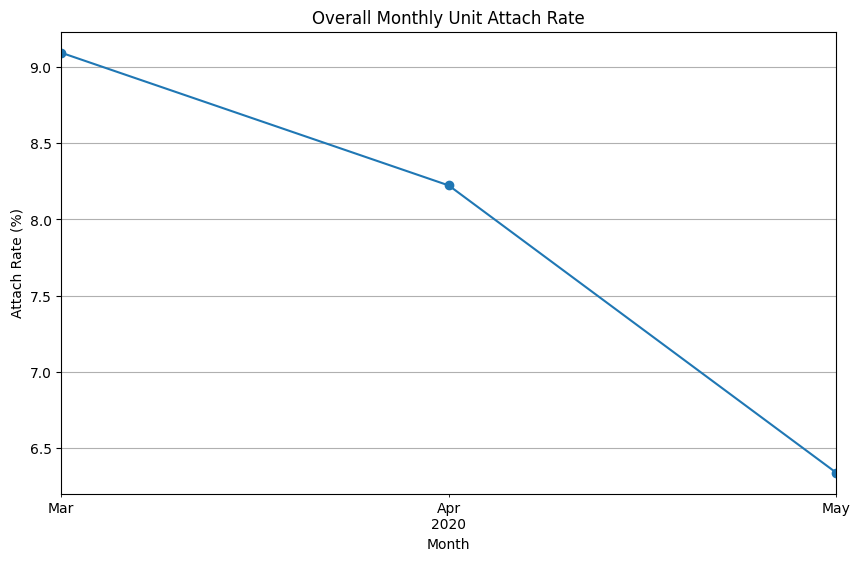

In [133]:
#line plot for overall monthly unit attach rate
monthly_attach_rate.plot(kind='line', figsize=(10, 6), marker='o')

plt.xlabel('Month')
plt.ylabel('Attach Rate (%)')
plt.title('Overall Monthly Unit Attach Rate')
plt.grid(True)

plt.show()

###Monthly Dollar Attach Rate

In [97]:
#calculate sales per month
orderlines_monthly['sales'] = orderlines_monthly['product_purchase_price'] * orderlines_monthly['quantity']

#warrantable sales for denominator
monthly_warrantable_sales = orderlines_monthly[orderlines_monthly['is_warrantable'] == True] \
                                              .groupby('month')['sales'].sum()

#warranty sales for numerator
monthly_warranty_sales = contract_validation[
    contract_validation['is_warrantable'] == True
].groupby('month')['plan_purchase_price'].sum()

#calculate attach rate
monthly_dollar_attach_rate = 100 * (monthly_warranty_sales / monthly_warrantable_sales)

monthly_dollar_attach_rate

,0
month,
2020-03,1.338446
2020-04,0.969878
2020-05,0.839405


The dollar attach rate for March is 1.34%, April is 0.97%, and May is 0.84%.

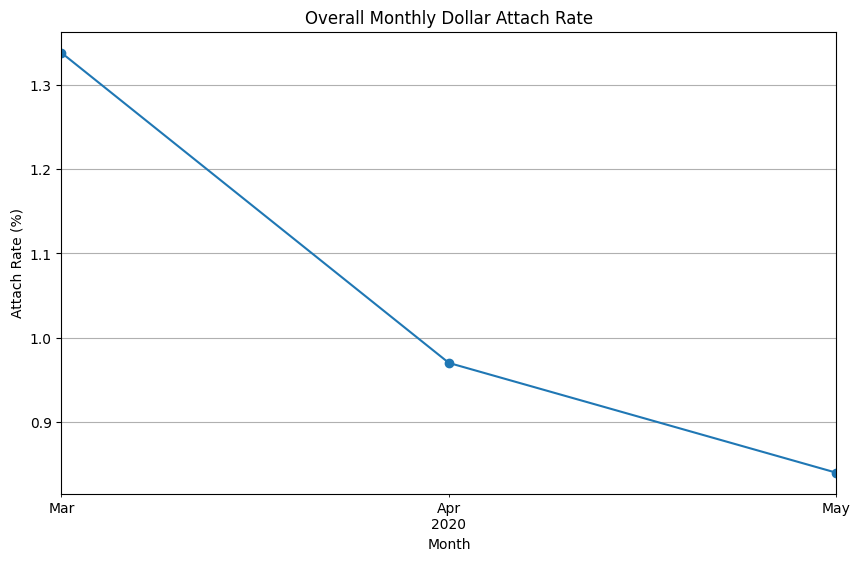

In [134]:
#lineplot for monthly overall in dollar
monthly_dollar_attach_rate.plot(kind='line', figsize=(10, 6), marker='o')

plt.xlabel('Month')
plt.ylabel('Attach Rate (%)')
plt.title('Overall Monthly Dollar Attach Rate')
plt.grid(True)

plt.show()

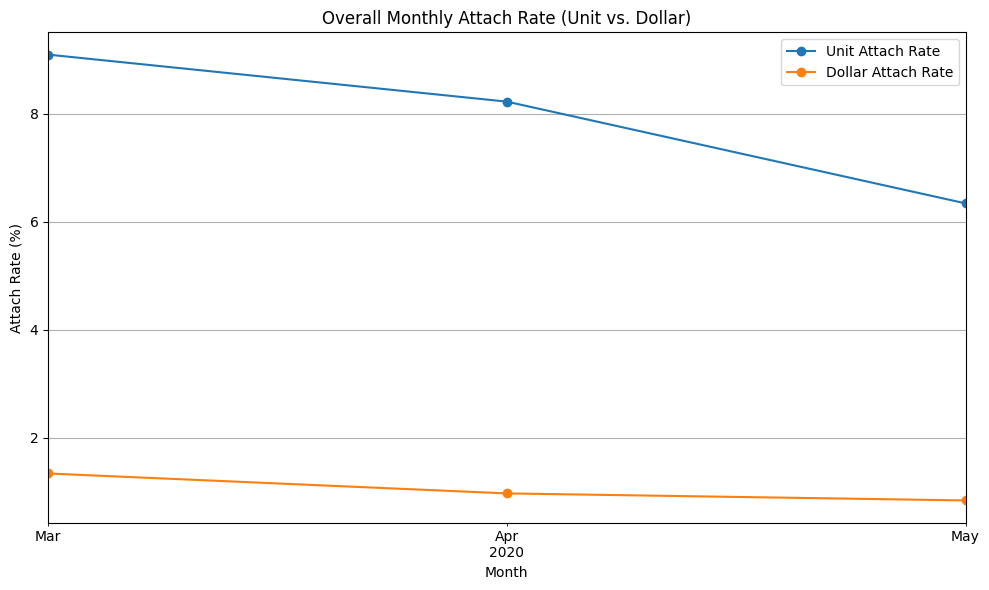

In [98]:
#lineplot for monthly overall in both unit
monthly_overall_attach_rate = pd.DataFrame({
    'Unit Attach Rate': monthly_attach_rate,
    'Dollar Attach Rate': monthly_dollar_attach_rate
})

monthly_overall_attach_rate.plot(kind='line', figsize=(10, 6), marker='o')

plt.xlabel('Month')
plt.ylabel('Attach Rate (%)')
plt.title('Overall Monthly Attach Rate (Unit vs. Dollar)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Attach Rate by Merchant

In [99]:
#merge orders & orderlines to bring in store_id
orderlines_merchants = orderlines.merge(
    orders[["order_id", "store_id"]],
    on="order_id",
    how="left",
    validate="many_to_one"
)

In [100]:
#warrantable units by merchant for denominator
merchant_warrantable_units = orderlines_merchants[orderlines_merchants['is_warrantable'] == True] \
  .groupby('store_id')['quantity'].sum()

#attached units by merchant for numerator
merchant_attached_units = contract_validation[
    contract_validation['is_warrantable'] == True
] \
.groupby('store_id')['contract_id'].nunique()

#calculate attach rate
merchant_unit_attach_rate = 100 * (merchant_attached_units / merchant_warrantable_units)

merchant_unit_attach_rate

,0
store_id,
0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,6.215921
2399c6c4-23d6-4d10-8810-b294c8cb3359,11.820160
2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,6.646856
2e1df809-4f73-4943-9bde-49fdbeddb8fc,9.460946
446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,13.212550
5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5,3.668262
661964ec-5d06-4dea-bbb2-56d3b9817a98,10.891871
780a27f2-578d-4455-818f-77b48453ffb9,17.679558
a5e80a29-c6af-446f-b569-f021e697c48c,14.290152


In [101]:
merchant_unit_attach_rate.rename("unit_attach_rate", inplace=True)

,unit_attach_rate
store_id,
0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,6.215921
2399c6c4-23d6-4d10-8810-b294c8cb3359,11.820160
2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,6.646856
2e1df809-4f73-4943-9bde-49fdbeddb8fc,9.460946
446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,13.212550
5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5,3.668262
661964ec-5d06-4dea-bbb2-56d3b9817a98,10.891871
780a27f2-578d-4455-818f-77b48453ffb9,17.679558
a5e80a29-c6af-446f-b569-f021e697c48c,14.290152


In [102]:
#merge to bring in merchant names
merchant_unit_attach = (
    merchant_unit_attach_rate
    .reset_index()
    .merge(
        merchants[["sortkey", "name", "storetype"]],
        left_on="store_id",
        right_on="sortkey",
        how="left",
        validate="many_to_one"
    )
)

In [103]:
#add warrantable & attached units to df
merchant_unit_attach = merchant_unit_attach.merge(
    merchant_warrantable_units.rename("warrantable_units"),
    on="store_id",
    how="left",
    validate="one_to_one"
)

merchant_unit_attach = merchant_unit_attach.merge(
    merchant_attached_units.rename("attached_units"),
    on="store_id",
    how="left",
    validate="one_to_one"
)

In [104]:
#attach rate results
merchant_unit_attach[[
    'name',
    'storetype',
    'warrantable_units',
    'attached_units',
    'unit_attach_rate']].sort_values(by='unit_attach_rate', ascending=False)

,name,storetype,warrantable_units,attached_units,unit_attach_rate
7,ElectricSkatePark,Sports & Fitness Equipment,181,32,17.679558
13,RefurbPCLand,Consumer Electronics,1051,159,15.128449
8,SecurityCamDirect,Home Security,3219,460,14.290152
4,SiiickHeadphones,Consumer Electronics,2263,299,13.212550
1,SkateboardsUSA,Sports & Fitness Equipment,1379,163,11.820160
6,FitnessWareables,Sports & Fitness Equipment,7602,828,10.891871
9,DietTrackers,Sports & Fitness Equipment,1006,97,9.642147
3,HVAC4U,Home and Garden,3636,344,9.460946
11,CarStereoIsland,Auto Parts & Electronics,4099,372,9.075384
2,HomeSecurityMart,Home Security,6394,425,6.646856


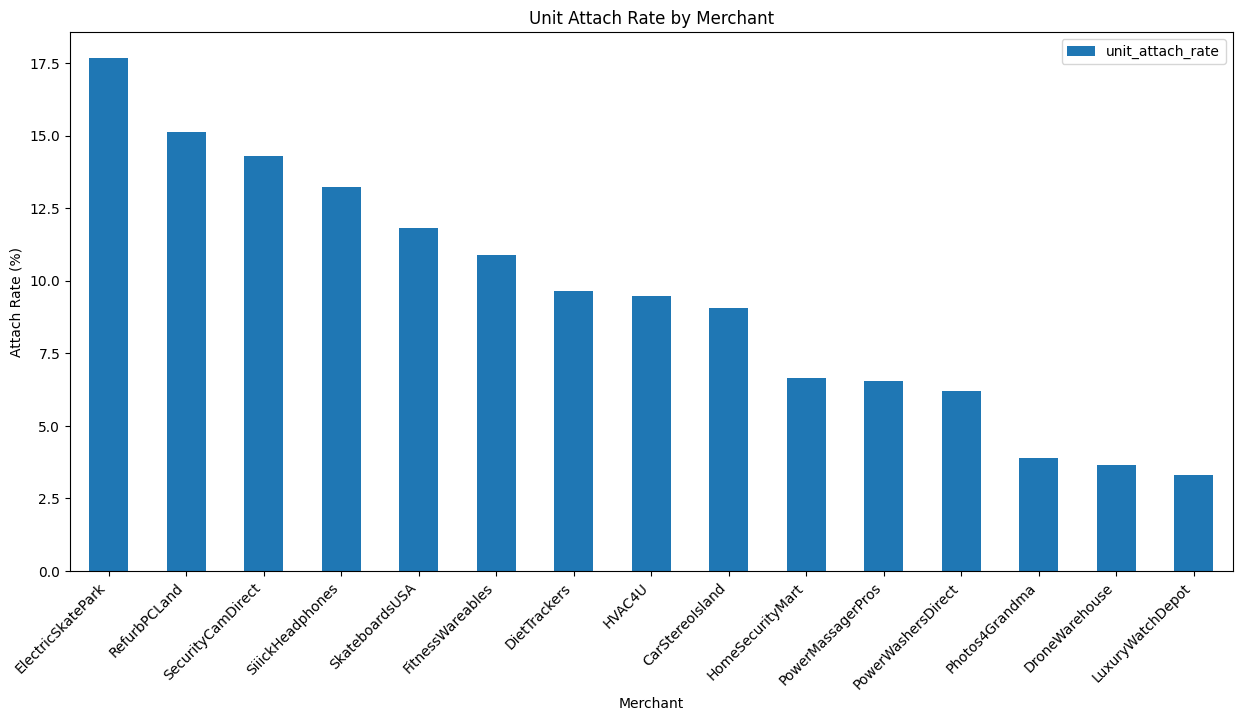

In [105]:
#plot in bar plot
merchant_unit_plot = merchant_unit_attach[[
    'name',
    'unit_attach_rate']].sort_values(by='unit_attach_rate', ascending=False).set_index('name')

merchant_unit_plot.plot(kind='bar', figsize = (15,7))

plt.xlabel('Merchant')
plt.ylabel('Attach Rate (%)')
plt.title('Unit Attach Rate by Merchant')

plt.xticks(rotation=45, ha='right')

plt.show()

Unit attach rate is highest for ElectricSkatePark but this also includes our lowest total attached units. The companies with our two highest possible warrantable units, Photos4Grandma, and DroneWarehouse are among the lowest in attach rate. This can be an area to further investigate for upside opportunities

In [106]:
#verify results
merchant_unit_attach['attached_units'].sum() / merchant_unit_attach['warrantable_units'].sum()

np.float64(0.07177588857169746)

This matches our overall unit attach rate, signaling that these results are accurate and valid.

###Merchant Dollar Attach Rate

In [107]:
#add sales to orderlines_merchant
orderlines_merchants['sales'] = orderlines_merchants['product_purchase_price'] * orderlines_merchants['quantity']

In [108]:
#merchant warrantable sales for denominator
merchant_warrantable_sales = orderlines_merchants[orderlines_merchants['is_warrantable'] == True] \
  .groupby('store_id')['sales'].sum()

#merchant warranty sales for numerator
merchant_warranty_sales = contract_validation[
    contract_validation['is_warrantable'] == True
] \
.groupby('store_id')['plan_purchase_price'].sum()

#calculate attach rate
merchant_dollar_attach_rate = 100 * (merchant_warranty_sales / merchant_warrantable_sales)

merchant_dollar_attach_rate.rename("dollar_attach_rate", inplace=True)

,dollar_attach_rate
store_id,
0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,0.779385
2399c6c4-23d6-4d10-8810-b294c8cb3359,1.623604
2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,1.150368
2e1df809-4f73-4943-9bde-49fdbeddb8fc,1.583439
446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,1.850093
5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5,0.643966
661964ec-5d06-4dea-bbb2-56d3b9817a98,1.646133
780a27f2-578d-4455-818f-77b48453ffb9,2.814395
a5e80a29-c6af-446f-b569-f021e697c48c,2.708019


In [109]:
#merge with merchants to get merchant names
merchant_dollar_attach = (
    merchant_dollar_attach_rate
    .reset_index()
    .merge(
        merchants[["sortkey", "name", "storetype"]],
        left_on="store_id",
        right_on="sortkey",
        how="left",
        validate="many_to_one"
    )
)

In [110]:
#bring in warrantable and warranty totals
merchant_dollar_attach = merchant_dollar_attach.merge(
    merchant_warrantable_sales.rename("warrantable_sales"),
    on="store_id",
    how="left",
    validate="one_to_one"
)

merchant_dollar_attach = merchant_dollar_attach.merge(
    merchant_warranty_sales.rename("warranty_sales"),
    on="store_id",
    how="left",
    validate="one_to_one"
)

In [111]:
formatted_dollar_attach = merchant_dollar_attach[[    'name',
    'storetype',
    'warrantable_sales',
    'warranty_sales',
    'dollar_attach_rate']].copy()

#format to remove scientific notation from warrantable sales
formatted_dollar_attach['warrantable_sales'] = formatted_dollar_attach['warrantable_sales'].apply(lambda x: f'{x:,.2f}')
formatted_dollar_attach['warranty_sales'] = formatted_dollar_attach['warranty_sales'].apply(lambda x: f'{x:,.2f}')

formatted_dollar_attach.sort_values(by='dollar_attach_rate', ascending=False)

,name,storetype,warrantable_sales,warranty_sales,dollar_attach_rate
7,ElectricSkatePark,Sports & Fitness Equipment,"123,359.00","3,471.81",2.814395
8,SecurityCamDirect,Home Security,"200,201.68","5,421.50",2.708019
13,RefurbPCLand,Consumer Electronics,"205,964.63","4,574.41",2.220969
4,SiiickHeadphones,Consumer Electronics,"218,027.37","4,033.71",1.850093
6,FitnessWareables,Sports & Fitness Equipment,"1,835,618.00","30,216.72",1.646133
9,DietTrackers,Sports & Fitness Equipment,"260,182.85","4,266.88",1.639954
1,SkateboardsUSA,Sports & Fitness Equipment,"2,292,477.36","37,220.76",1.623604
3,HVAC4U,Home and Garden,"1,202,267.67","19,037.18",1.583439
2,HomeSecurityMart,Home Security,"1,401,929.76","16,127.35",1.150368
14,PowerMassagerPros,Sports & Fitness Equipment,"1,487,551.53","16,216.06",1.090118


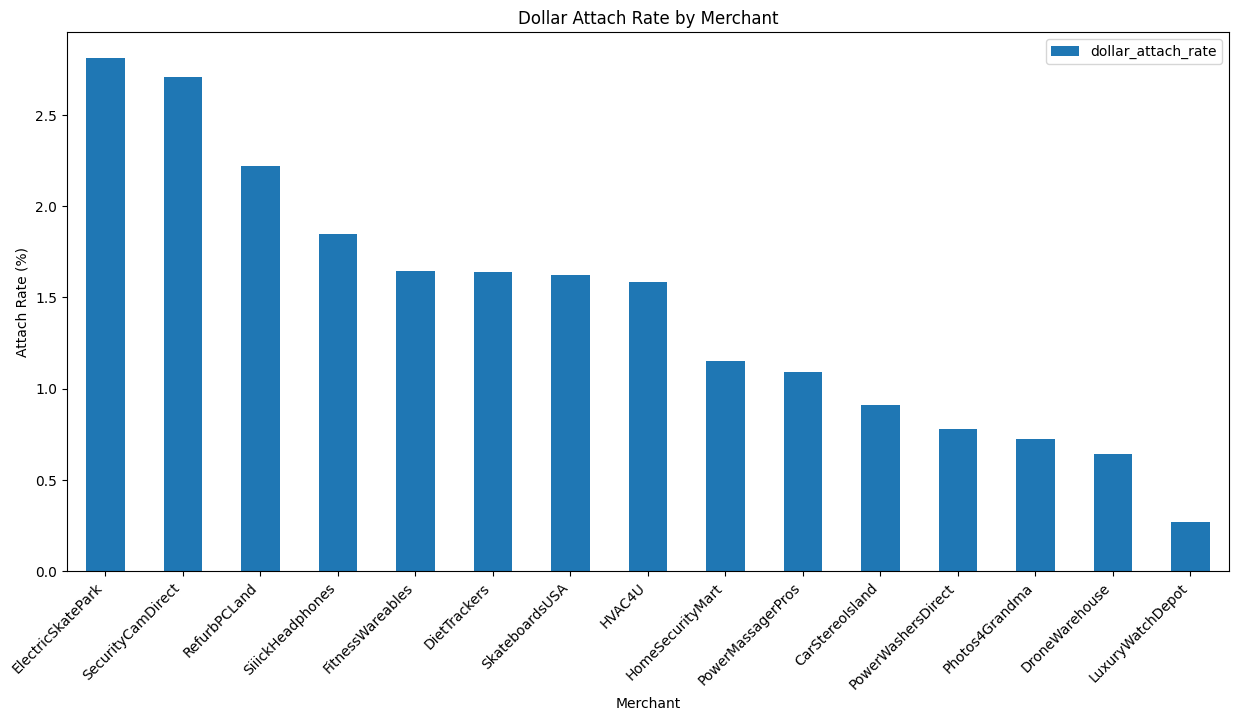

In [112]:
#plot in bar plot
merchant_dollar_plot = merchant_dollar_attach[[
    'name',
    'dollar_attach_rate']].sort_values(by='dollar_attach_rate', ascending=False).set_index('name')

merchant_dollar_plot.plot(kind='bar', figsize = (15,7))

plt.xlabel('Merchant')
plt.ylabel('Attach Rate (%)')
plt.title('Dollar Attach Rate by Merchant')

plt.xticks(rotation=45, ha='right')

plt.show()

While attach rate is highest for ElectricSkatePark, it is driving one of the lowest sale values. There are opportunities to increase revenue by increasing attach rate of LuxuryWatchDepot, SkateboardsUSA, and FitnessWearables as they are the highest grossing merchants.

In [113]:
#verify results
merchant_dollar_attach['warranty_sales'].sum() / merchant_dollar_attach['warrantable_sales'].sum()

np.float64(0.009298619032411404)

This matches the 0.93 from our overall result which verifies the results match what we expect here.

##Monthly Unit & Dollar Merchant Analysis

In [114]:
#bring store_id to orderlines monthly table
orderlines_monthly = orderlines_monthly.merge(
    orders[["order_id", "store_id"]],
    on="order_id",
    how="left",
    validate="many_to_one"
)

orderlines_monthly.head()

,line_item_id,order_id,variant_id,quantity,price,product_purchase_price,discount_per_item,is_warrantable,is_warranty,ordered_at,month,sales,store_id
0,4730634797174,2141983408246,3.131829e+13,1,25.0,25.0,0.0,False,False,2020-04-17 21:14:34+00:00,2020-04,25.0,661964ec-5d06-4dea-bbb2-56d3b9817a98
1,4841816752246,2194646532214,3.109589e+13,1,229.0,229.0,0.0,True,False,2020-05-08 02:46:55+00:00,2020-05,229.0,661964ec-5d06-4dea-bbb2-56d3b9817a98
2,4830647713910,2189327073398,3.109589e+13,3,229.0,229.0,0.0,True,False,2020-05-06 01:57:13+00:00,2020-05,687.0,661964ec-5d06-4dea-bbb2-56d3b9817a98
3,4818776522870,2183841480822,3.109589e+13,1,229.0,229.0,0.0,True,False,2020-05-04 00:53:50+00:00,2020-05,229.0,661964ec-5d06-4dea-bbb2-56d3b9817a98
4,4816728326262,2183031095414,3.109589e+13,2,229.0,229.0,0.0,True,False,2020-05-03 19:32:52+00:00,2020-05,458.0,661964ec-5d06-4dea-bbb2-56d3b9817a98


In [115]:
#get warrantable units by merchant by month for denominator
merchant_monthly_warrantable = orderlines_monthly[orderlines_monthly['is_warrantable'] == True] \
  .groupby(['store_id', 'month'])['quantity'].sum()

#get attached units by merchant by month for numerator
merchant_monthly_attached = contract_validation[
    contract_validation['is_warrantable'] == True
] \
.groupby(['store_id', 'month'])['contract_id'].nunique()

print(merchant_monthly_warrantable)
print(merchant_monthly_attached)

store_id                              month  
0d92cbe4-2d26-4c81-ae4e-7ace36b6700b  2020-03       11
                                      2020-04      333
                                      2020-05      573
2399c6c4-23d6-4d10-8810-b294c8cb3359  2020-03      320
                                      2020-04      518
                                      2020-05      541
2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b  2020-03     1060
                                      2020-04     1119
                                      2020-05     4215
2e1df809-4f73-4943-9bde-49fdbeddb8fc  2020-03      773
                                      2020-04     1226
                                      2020-05     1637
446af1d1-22e5-41cb-bbb1-dc6e7ad970b4  2020-03      382
                                      2020-04      806
                                      2020-05     1075
5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5  2020-05    11913
661964ec-5d06-4dea-bbb2-56d3b9817a98  2020-03      419
                   

In [116]:
#calculate attach rate
merchant_monthly_attach_rate = 100 * (merchant_monthly_attached / merchant_monthly_warrantable)

merchant_monthly_attach_rate

store_id                              month  
0d92cbe4-2d26-4c81-ae4e-7ace36b6700b  2020-03     9.090909
                                      2020-04     9.009009
                                      2020-05     4.537522
2399c6c4-23d6-4d10-8810-b294c8cb3359  2020-03    13.750000
                                      2020-04     9.845560
                                      2020-05    12.569316
2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b  2020-03     8.584906
                                      2020-04     7.238606
                                      2020-05     6.002372
2e1df809-4f73-4943-9bde-49fdbeddb8fc  2020-03     7.632600
                                      2020-04     7.993475
                                      2020-05    11.423335
446af1d1-22e5-41cb-bbb1-dc6e7ad970b4  2020-03    11.780105
                                      2020-04    15.756824
                                      2020-05    11.813953
5dfad31f-9dc6-4e02-b8ba-ad59d42fa8d5  2020-05     3.668262
661964ec-5d06-4dea-bbb2-56d3b9817a98  2020-03    10.262530
                                      2020-04    11.020212
                                      2020-05    10.891283
780a27f2-578d-4455-818f-77b48453ffb9  2020-03    13.043478
                                      2020-04    15.517241
                                      2020-05    20.000000
a5e80a29-c6af-446f-b569-f021e697c48c  2020-03    17.605634
                                      2020-04    17.684377
                                      2020-05     8.974359
c18e4014-49ee-4f3d-8813-c7a9f2e407b9  2020-04     5.442177
                                      2020-05    10.360885
cbc0b107-7112-4a84-9a5f-a1cfdcfcfdbd  2020-03     3.666921
                                      2020-04     3.790688
                                      2020-05     4.022912
cbd9a3a0-8457-4bd9-abf6-5de6b62da6c2  2020-03    10.333692
                                      2020-04     9.029650
                                      2020-05     8.422301
d2d139d8-f36d-4183-bc9d-61353623036c  2020-04     2.816901
                                      2020-05     3.475239
fb650744-0bf1-4662-a98c-b7a35f5f540f  2020-03    12.796698
                                      2020-04    42.682927
fd8f6538-a246-4fc8-b179-ca40fccfbb25  2020-03     5.157814
                                      2020-04     6.334842
                                      2020-05     7.953817
dtype: float64

In [117]:
merchant_monthly_attach_rate.rename("unit_attach_rate", inplace=True)

#merge with merchants to bring in store names & industry
merchant_monthly_attach_rate = (
    merchant_monthly_attach_rate
    .reset_index()
    .merge(
        merchants[["sortkey", "name", "storetype"]],
        left_on="store_id",
        right_on="sortkey",
        how="left",
        validate="many_to_one"
    )
)

In [118]:
#bring in warrantable/warranty units
merchant_monthly_attach_rate = merchant_monthly_attach_rate.merge(
    merchant_monthly_warrantable.rename("warrantable_units"),
    on=["store_id", "month"],
    how="left",
    validate="many_to_one"
)

merchant_monthly_attach_rate = merchant_monthly_attach_rate.merge(
    merchant_monthly_attached.rename("attached_units"),
    on=["store_id", "month"],
    how="left",
    validate="many_to_one"
)

In [119]:
#create table of attach rates by month
merchant_monthly_attach_rate[[
    'name',
    'storetype',
    'month',
    'warrantable_units',
    'attached_units',
    'unit_attach_rate']].sort_values(by=['name', 'month'], ascending=False)

,name,storetype,month,warrantable_units,attached_units,unit_attach_rate
5,SkateboardsUSA,Sports & Fitness Equipment,2020-05,541,68,12.569316
4,SkateboardsUSA,Sports & Fitness Equipment,2020-04,518,51,9.845560
3,SkateboardsUSA,Sports & Fitness Equipment,2020-03,320,44,13.750000
14,SiiickHeadphones,Consumer Electronics,2020-05,1075,127,11.813953
13,SiiickHeadphones,Consumer Electronics,2020-04,806,127,15.756824
12,SiiickHeadphones,Consumer Electronics,2020-03,382,45,11.780105
24,SecurityCamDirect,Home Security,2020-05,1248,112,8.974359
23,SecurityCamDirect,Home Security,2020-04,1261,223,17.684377
22,SecurityCamDirect,Home Security,2020-03,710,125,17.605634
36,RefurbPCLand,Consumer Electronics,2020-04,82,35,42.682927


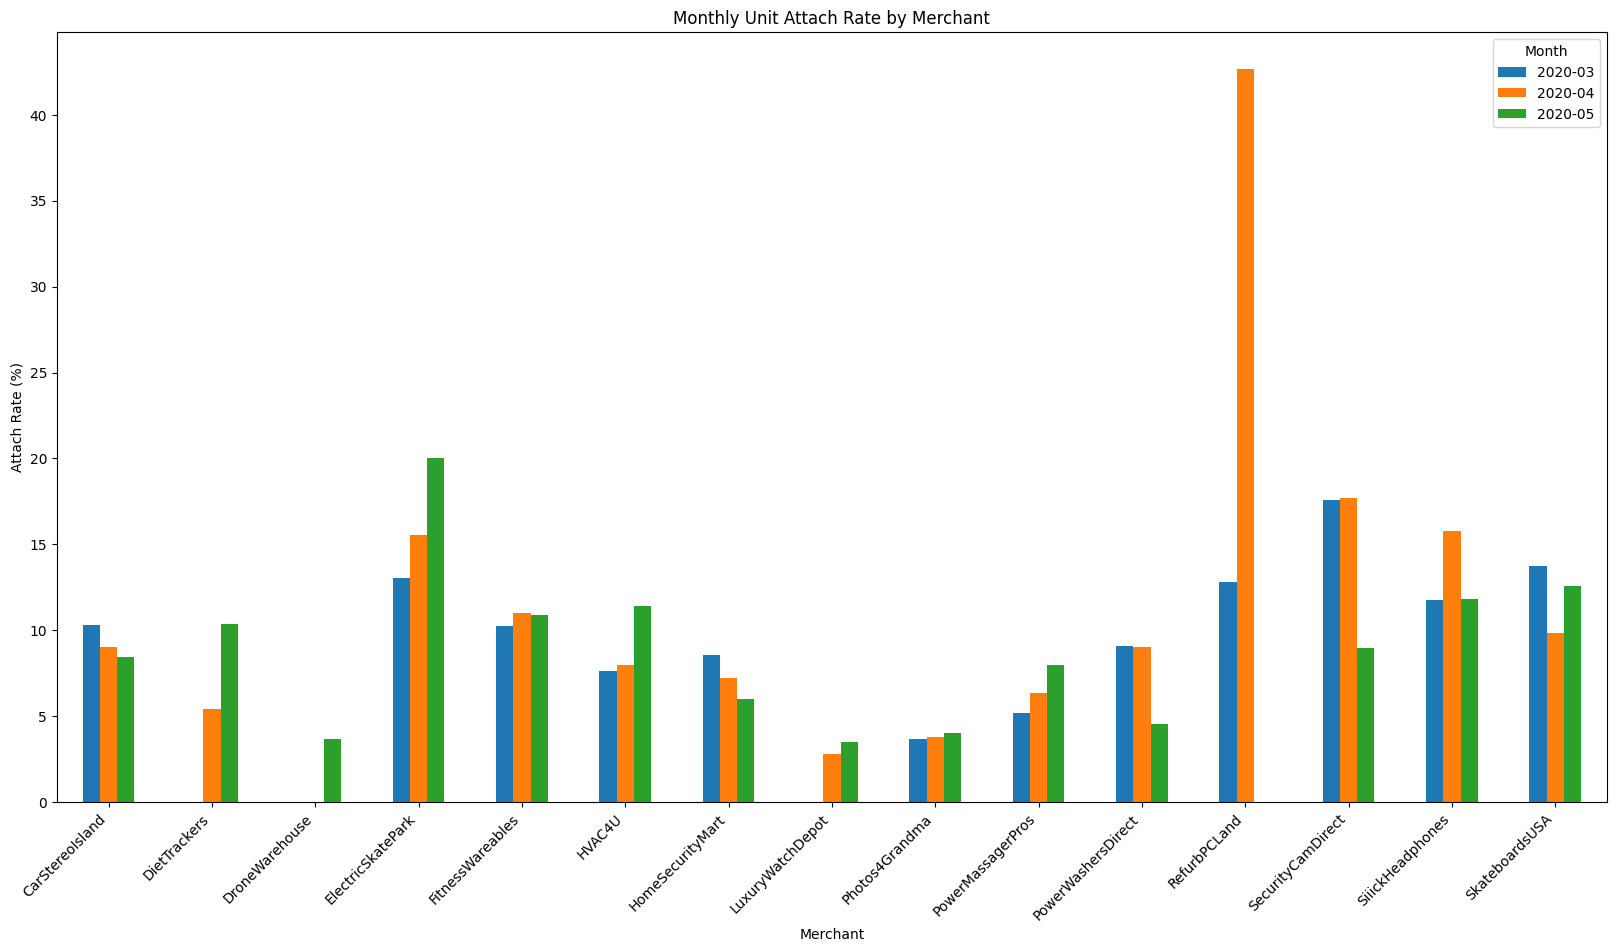

In [120]:
#Visualize in bar chart
#pivot table for easier visualization
merchant_monthly_pivot = merchant_monthly_attach_rate.pivot(
    index='name',
    columns='month',
    values='unit_attach_rate'
)

#plot in grouped bar plot
merchant_monthly_pivot.plot(kind='bar', figsize = (20,10))

plt.xlabel('Merchant')
plt.ylabel('Attach Rate (%)')
plt.title('Monthly Unit Attach Rate by Merchant')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Month')

plt.show()

RefurbPCLand had a big spike in attach rate but this was only among 82 orders in April 2020. ElectricSkatePark saw a steady increase in attach rate by unit.

In [121]:
#warrantable dollars for denominator
merchant_monthly_warrantable_dollars = orderlines_monthly[orderlines_monthly['is_warrantable'] == True] \
  .groupby(['store_id', 'month'])['sales'].sum()

#warranty dollars for numerator
merchant_monthly_warranty_dollars = contract_validation[
    contract_validation['is_warrantable'] == True
] \
.groupby(['store_id', 'month'])['plan_purchase_price'].sum()

#calculate attach rate
merchant_monthly_dollar_attach_rate = 100 * (merchant_monthly_warranty_dollars / merchant_monthly_warrantable_dollars)

#rename column
merchant_monthly_dollar_attach_rate.rename("dollar_attach_rate", inplace=True)

#bring in merchant names and storetype
merchant_monthly_dollar_attach_rate = (
    merchant_monthly_dollar_attach_rate
    .reset_index()
    .merge(
        merchants[["sortkey", "name", "storetype"]],
        left_on="store_id",
        right_on="sortkey",
        how="left",
        validate="many_to_one"
    )
)

In [122]:
#add in totals for warrantable sales and warranty sales
merchant_monthly_dollar_attach_rate = merchant_monthly_dollar_attach_rate.merge(
    merchant_monthly_warrantable_dollars.rename("warrantable_sales"),
    on=["store_id", "month"],
    how="left",
    validate="many_to_one"
)

merchant_monthly_dollar_attach_rate = merchant_monthly_dollar_attach_rate.merge(
    merchant_monthly_warranty_dollars.rename("warranty_sales"),
    on=["store_id", "month"],
    how="left",
    validate="many_to_one"
)

In [123]:

formatted_monthly_dollar = merchant_monthly_dollar_attach_rate[[
    'name',
    'storetype',
    'month',
    'warrantable_sales',
    'warranty_sales',
    'dollar_attach_rate']].copy()

#formatting to remove scientific notation from warrantable sales
formatted_monthly_dollar['warrantable_sales'] = formatted_monthly_dollar['warrantable_sales'].apply(lambda x: f'{x:,.2f}')
formatted_monthly_dollar['warranty_sales'] = formatted_monthly_dollar['warranty_sales'].apply(lambda x: f'{x:,.2f}')


formatted_monthly_dollar.sort_values(by=['name', 'month'], ascending=False)

,name,storetype,month,warrantable_sales,warranty_sales,dollar_attach_rate
5,SkateboardsUSA,Sports & Fitness Equipment,2020-05,"924,465.30","17,782.00",1.923490
4,SkateboardsUSA,Sports & Fitness Equipment,2020-04,"825,427.10","11,229.89",1.360494
3,SkateboardsUSA,Sports & Fitness Equipment,2020-03,"542,584.96","8,208.87",1.512919
14,SiiickHeadphones,Consumer Electronics,2020-05,"110,459.25","1,739.73",1.574997
13,SiiickHeadphones,Consumer Electronics,2020-04,"74,281.94","1,803.53",2.427952
12,SiiickHeadphones,Consumer Electronics,2020-03,"33,286.18",490.45,1.473434
24,SecurityCamDirect,Home Security,2020-05,"75,446.63","1,327.98",1.760158
23,SecurityCamDirect,Home Security,2020-04,"78,134.36","2,666.47",3.412673
22,SecurityCamDirect,Home Security,2020-03,"46,620.69","1,427.05",3.060980
36,RefurbPCLand,Consumer Electronics,2020-04,"17,646.12","1,128.65",6.396024


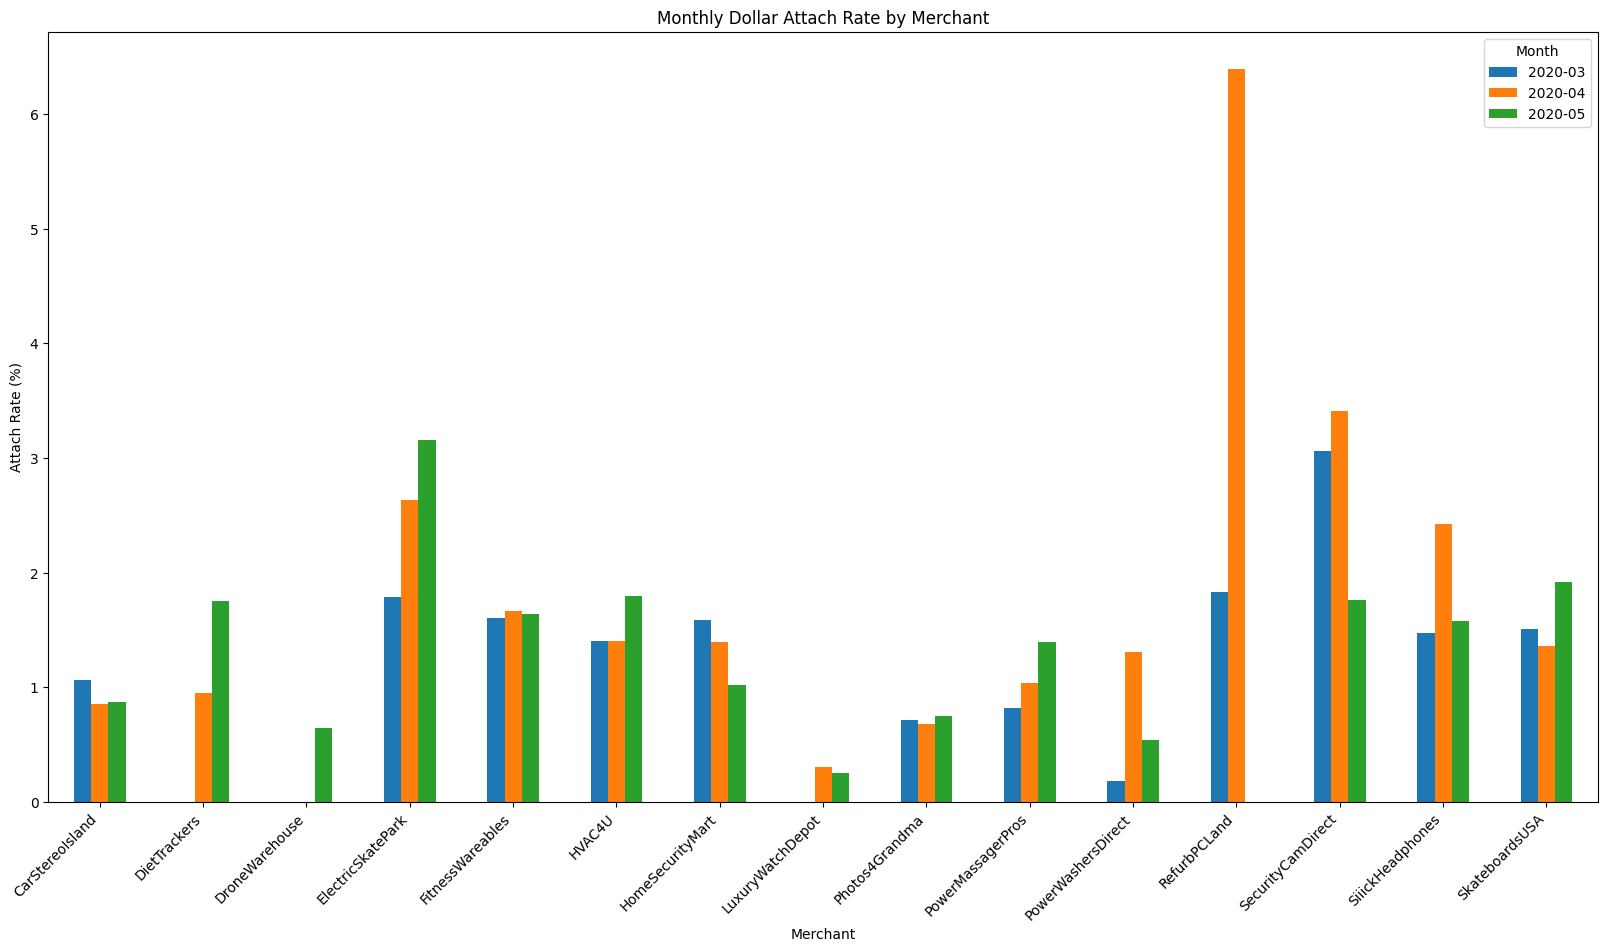

In [124]:
#grouped bar chart
merchant_monthly_dollar_pivot = merchant_monthly_dollar_attach_rate.pivot(
    index='name',
    columns='month',
    values='dollar_attach_rate'
)

merchant_monthly_dollar_pivot.plot(kind='bar', figsize = (20,10))

plt.xlabel('Merchant')
plt.ylabel('Attach Rate (%)')
plt.title('Monthly Dollar Attach Rate by Merchant')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Month')

plt.show()

These results are very similar to the unit results. RefurbPCLand had the best attach rate per month with 6.40% in April 2020. FitnessWearables had a consisten attach rate through all months but had the largest dollar share, bringing in nearly 20K in warranty in May 2020.

# Industry Opportunity Analysis

## Current performance by industry


In [125]:
#unit attach rate by industry
industry_units = (
    merchant_unit_attach
    .groupby('storetype')
    .agg({
        'warrantable_units': 'sum',
        'attached_units': 'sum'
    })
)

industry_units['unit_attach_rate'] = 100 * (industry_units['attached_units'] / industry_units['warrantable_units'])

industry_units.sort_values(by='unit_attach_rate', ascending=False)

,warrantable_units,attached_units,unit_attach_rate
storetype,,,
Sports & Fitness Equipment,15015,1437,9.570430
Home Security,9613,885,9.206283
Auto Parts & Electronics,4099,372,9.075384
Home and Garden,4553,401,8.807380
Consumer Electronics,28897,1429,4.945150
Watches & Jewelry,1577,52,3.297400


The top 4 industries are all within a percentage point on attach rate so they are very comparable. Sports & Fitness has the most attached units and has 15K warrantable units showing this could be a sustainable area for Extend.

There is a dip in attach rate for Consumer Electronics and Watches and Jewelry. Consumer Electronics has our most units sold so this may indicate it is not as strong of a market for Extend. While Watches & Jewelry is the smallest market and could still have potential for opportunity.

In [126]:
#dollar attach rate by industry
industry_dollars = (
    merchant_dollar_attach
    .groupby('storetype')
    .agg({
        'warrantable_sales': 'sum',
        'warranty_sales': 'sum'
    })
)

industry_dollars['dollar_attach_rate'] = 100 * (industry_dollars['warranty_sales'] / industry_dollars['warrantable_sales'])

industry_dollars.sort_values(by='dollar_attach_rate', ascending=False)

,warrantable_sales,warranty_sales,dollar_attach_rate
storetype,,,
Sports & Fitness Equipment,5.999189e+06,91392.23,1.523410
Home and Garden,1.508033e+06,21420.27,1.420411
Home Security,1.602131e+06,21548.85,1.345011
Auto Parts & Electronics,5.587560e+05,5096.21,0.912064
Consumer Electronics,3.078495e+06,27386.71,0.889614
Watches & Jewelry,7.293175e+06,19498.00,0.267346


The results for dollar value are somewhat similar. Sports & Fitness has the highest attach rate and has brought in by far the most revenue. Consumer Electronics brought in the 2nd highest overall revenue but the attach rate was still one of the two lowest.

Watches & Jewelry has the lowest attach rate here as well but has the highest warrantable sales value. This could be a great market opportunity even if attach rate stays low.

In [127]:
#combine them for total industry analysis
industry_analysis = industry_units.merge(
    industry_dollars,
    on='storetype',
    how='left',
    validate='one_to_one'
)

industry_analysis

,warrantable_units,attached_units,unit_attach_rate,warrantable_sales,warranty_sales,dollar_attach_rate
storetype,,,,,,
Auto Parts & Electronics,4099,372,9.075384,5.587560e+05,5096.21,0.912064
Consumer Electronics,28897,1429,4.945150,3.078495e+06,27386.71,0.889614
Home Security,9613,885,9.206283,1.602131e+06,21548.85,1.345011
Home and Garden,4553,401,8.807380,1.508033e+06,21420.27,1.420411
Sports & Fitness Equipment,15015,1437,9.570430,5.999189e+06,91392.23,1.523410
Watches & Jewelry,1577,52,3.297400,7.293175e+06,19498.00,0.267346


This combines them for a more digestible view. We can see here how the units and dollar values differ. Watches & Jewelry has the lowest unit count but largest market opportunity. It may be worthwhile to focus more on that industry and less on an industry like Consumer Electronics where the attach rate is amonth the lowest but we have the highest unit count.

## Extend Net Revenue

This is defined as Warranty Sales x (1 - merchant cut). I'll calculate the net revenue at the merchant level to ensure accuracy.

In [128]:
#add merchant cut to merchant_dollar_attach
merchant_revenue = merchant_dollar_attach.merge(
    merchants[['sortkey', 'merchantcut']],
    left_on='store_id',
    right_on='sortkey',
    how='left',
    validate='many_to_one'
)

merchant_revenue['net_revenue'] = merchant_revenue['warranty_sales'] * (1 - merchant_revenue['merchantcut'])

merchant_revenue.head()

,store_id,dollar_attach_rate,sortkey_x,name,storetype,warrantable_sales,warranty_sales,sortkey_y,merchantcut,net_revenue
0,0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,0.779385,0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,PowerWashersDirect,Home and Garden,3.057654e+05,2383.09,0d92cbe4-2d26-4c81-ae4e-7ace36b6700b,0.25,1787.3175
1,2399c6c4-23d6-4d10-8810-b294c8cb3359,1.623604,2399c6c4-23d6-4d10-8810-b294c8cb3359,SkateboardsUSA,Sports & Fitness Equipment,2.292477e+06,37220.76,2399c6c4-23d6-4d10-8810-b294c8cb3359,0.30,26054.5320
2,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,1.150368,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,HomeSecurityMart,Home Security,1.401930e+06,16127.35,2798ad2f-a9cb-4ed0-b787-30ea6b2dfc2b,0.25,12095.5125
3,2e1df809-4f73-4943-9bde-49fdbeddb8fc,1.583439,2e1df809-4f73-4943-9bde-49fdbeddb8fc,HVAC4U,Home and Garden,1.202268e+06,19037.18,2e1df809-4f73-4943-9bde-49fdbeddb8fc,0.35,12374.1670
4,446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,1.850093,446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,SiiickHeadphones,Consumer Electronics,2.180274e+05,4033.71,446af1d1-22e5-41cb-bbb1-dc6e7ad970b4,0.25,3025.2825


In [129]:
#aggregate by industry
industry_revenue = (
    merchant_revenue
    .groupby('storetype')
    .agg({
        'warranty_sales': 'sum',
        'net_revenue': 'sum'
    })
    .reset_index()
)

industry_revenue.sort_values(by='net_revenue', ascending=False)

,storetype,warranty_sales,net_revenue
4,Sports & Fitness Equipment,91392.23,65132.5450
1,Consumer Electronics,27386.71,19440.5065
2,Home Security,21548.85,16161.6375
3,Home and Garden,21420.27,14161.4845
5,Watches & Jewelry,19498.00,12673.7000
0,Auto Parts & Electronics,5096.21,3822.1575


This proves again that Sports & Fitness is a top industry. It is bringing in more than 3x any other industry in net revenue. While Consumer Electronics lagged behind in attach rate, it is still a strong driver of revenue.

Auto Parts & Electronics was in the middle of the pack in attach rate but is by fare the lowest in sales and revenue.

##Market Opportunity

In [130]:
#create decision table
industry_decision = industry_analysis.merge(
    industry_revenue,
    on='storetype',
    how='left',
    validate='one_to_one'
)

industry_decision.sort_values(by='net_revenue', ascending=False)

,storetype,warrantable_units,attached_units,unit_attach_rate,warrantable_sales,warranty_sales_x,dollar_attach_rate,warranty_sales_y,net_revenue
4,Sports & Fitness Equipment,15015,1437,9.570430,5.999189e+06,91392.23,1.523410,91392.23,65132.5450
1,Consumer Electronics,28897,1429,4.945150,3.078495e+06,27386.71,0.889614,27386.71,19440.5065
2,Home Security,9613,885,9.206283,1.602131e+06,21548.85,1.345011,21548.85,16161.6375
3,Home and Garden,4553,401,8.807380,1.508033e+06,21420.27,1.420411,21420.27,14161.4845
5,Watches & Jewelry,1577,52,3.297400,7.293175e+06,19498.00,0.267346,19498.00,12673.7000
0,Auto Parts & Electronics,4099,372,9.075384,5.587560e+05,5096.21,0.912064,5096.21,3822.1575


In [131]:
#drop duplicate columns and reformat 'warrantable_sales'
industry_decision.drop(columns=['warranty_sales_y'], inplace=True)
industry_decision['warrantable_sales'] = industry_decision['warrantable_sales'].apply(lambda x: f'{x:,.2f}')

In [132]:
industry_decision.sort_values(by='net_revenue', ascending=False)

,storetype,warrantable_units,attached_units,unit_attach_rate,warrantable_sales,warranty_sales_x,dollar_attach_rate,net_revenue
4,Sports & Fitness Equipment,15015,1437,9.570430,"5,999,188.74",91392.23,1.523410,65132.5450
1,Consumer Electronics,28897,1429,4.945150,"3,078,494.76",27386.71,0.889614,19440.5065
2,Home Security,9613,885,9.206283,"1,602,131.44",21548.85,1.345011,16161.6375
3,Home and Garden,4553,401,8.807380,"1,508,033.03",21420.27,1.420411,14161.4845
5,Watches & Jewelry,1577,52,3.297400,"7,293,175.00",19498.00,0.267346,12673.7000
0,Auto Parts & Electronics,4099,372,9.075384,"558,755.99",5096.21,0.912064,3822.1575


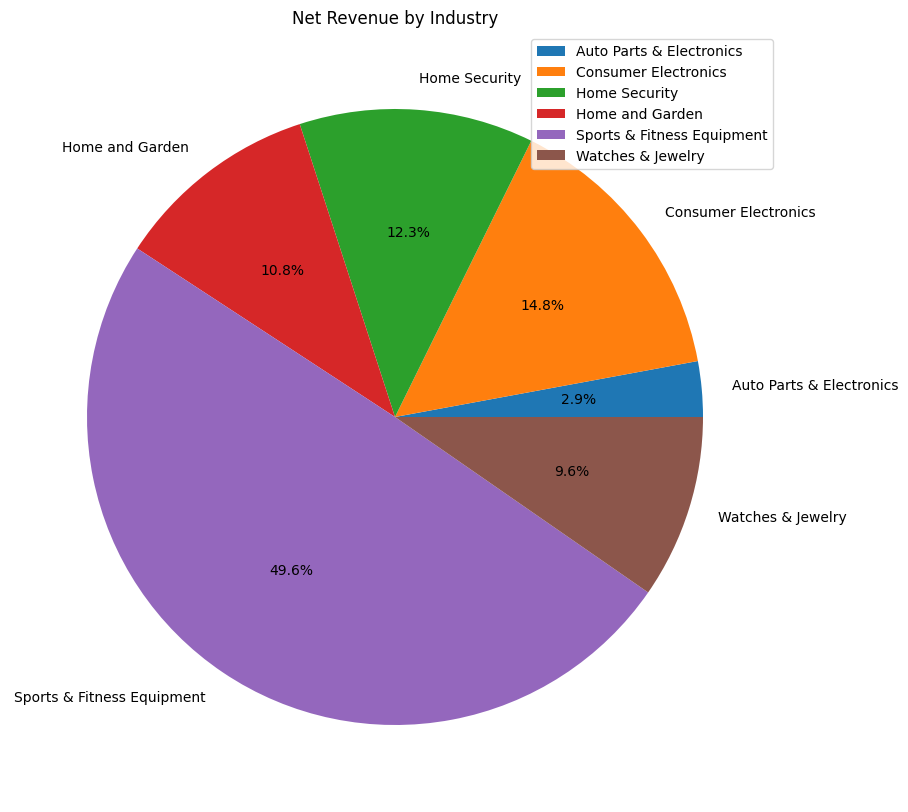

In [135]:
#pie chart for net_revenue
industry_decision.plot(
    kind='pie',
    y='net_revenue',
    labels=industry_decision['storetype'],
    autopct='%1.1f%%',
    figsize=(10,10)
)
plt.title('Net Revenue by Industry')
plt.ylabel('')
plt.show()

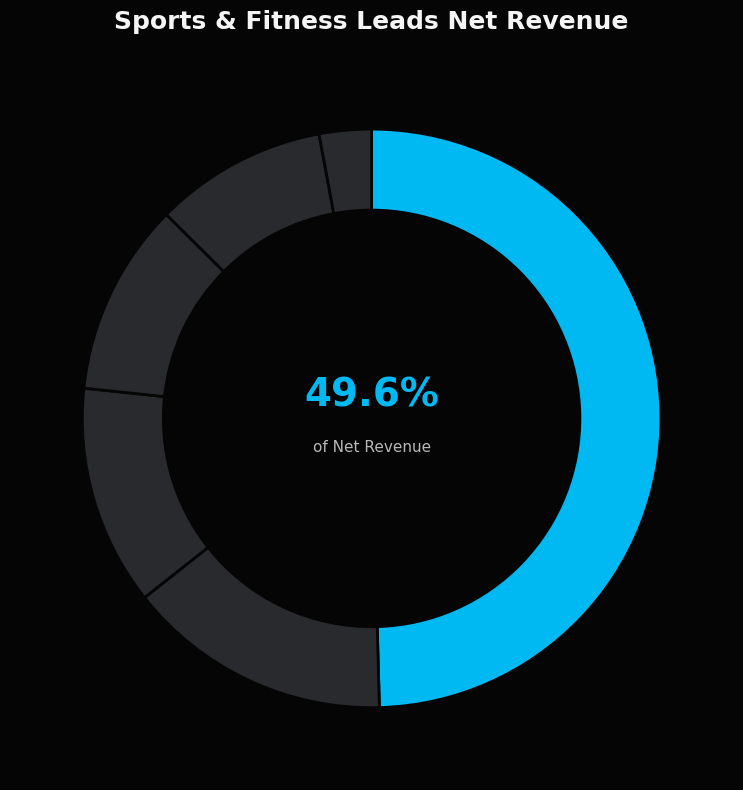

In [141]:
#align with extend branding
fig, ax = plt.subplots(figsize=(8, 8))

fig.patch.set_facecolor("#050505")
ax.set_facecolor("#050505")

colors = [
    "#00B9F2" if x == "Sports & Fitness Equipment"
    else "#282A2D"
    for x in plot_data["storetype"]
]

ax.pie(
    plot_data["net_revenue"],
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={
        "width": 0.28,
        "edgecolor": "#050505",
        "linewidth": 2
    }
)

# Center text
ax.text(
    0, 0.08,
    "49.6%",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold",
    color="#00B9F2"
)

ax.text(
    0, -0.10,
    "of Net Revenue",
    ha="center",
    va="center",
    fontsize=11,
    color="#B8B8B8"
)

ax.set_title(
    "Sports & Fitness Leads Net Revenue",
    color="#F5F5F5"
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

### Market Sizes
I'm researching the market sizes for Sports & Fitness, Home Security, and Watches & Jewelry. I'm selecting these as they are strong performing markets or arease for growth for Extend

**Sports & Fitness Equipment**

The US Census Bureau reported 58B in 2023 sales in US sporting goods stores and specifies it includes sporting equipment, exercise/fitness eqipment, bicycles, and camping gear. SFIA reports 130B in 2025 but this includes broader categories like footwear, apparel, and merchandise. We will use the 58B number from 2023 as that is the most recent reliable figure.

**Home Security**

Grand View Research estimates the US smart home security market at 12.15B in 2025 with potential to grow to 26B by 2033.

**Watches & Jewelry**

Grand View Research estimates the US jewelry market to be 78.4B. This a large underlying market even without accounting for luxury watches.

In [142]:
#add market sizes to industry decision
market_sizes = {
    "Sports & Fitness Equipment": 58.0,
    "Home Security": 12.15,
    "Home and Garden": 372.0,
    "Consumer Electronics": 241.2,
    "Watches & Jewelry": 78.4,
    "Auto Parts & Electronics": 85.0
}

industry_decision['market_size'] = industry_decision['storetype'].map(market_sizes)

industry_decision.sort_values(by='net_revenue', ascending=False)

,storetype,warrantable_units,attached_units,unit_attach_rate,warrantable_sales,warranty_sales_x,dollar_attach_rate,net_revenue,market_size
4,Sports & Fitness Equipment,15015,1437,9.570430,"5,999,188.74",91392.23,1.523410,65132.5450,58.00
1,Consumer Electronics,28897,1429,4.945150,"3,078,494.76",27386.71,0.889614,19440.5065,241.20
2,Home Security,9613,885,9.206283,"1,602,131.44",21548.85,1.345011,16161.6375,12.15
3,Home and Garden,4553,401,8.807380,"1,508,033.03",21420.27,1.420411,14161.4845,372.00
5,Watches & Jewelry,1577,52,3.297400,"7,293,175.00",19498.00,0.267346,12673.7000,78.40
0,Auto Parts & Electronics,4099,372,9.075384,"558,755.99",5096.21,0.912064,3822.1575,85.00


/tmp/ipykernel_830/3758679334.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


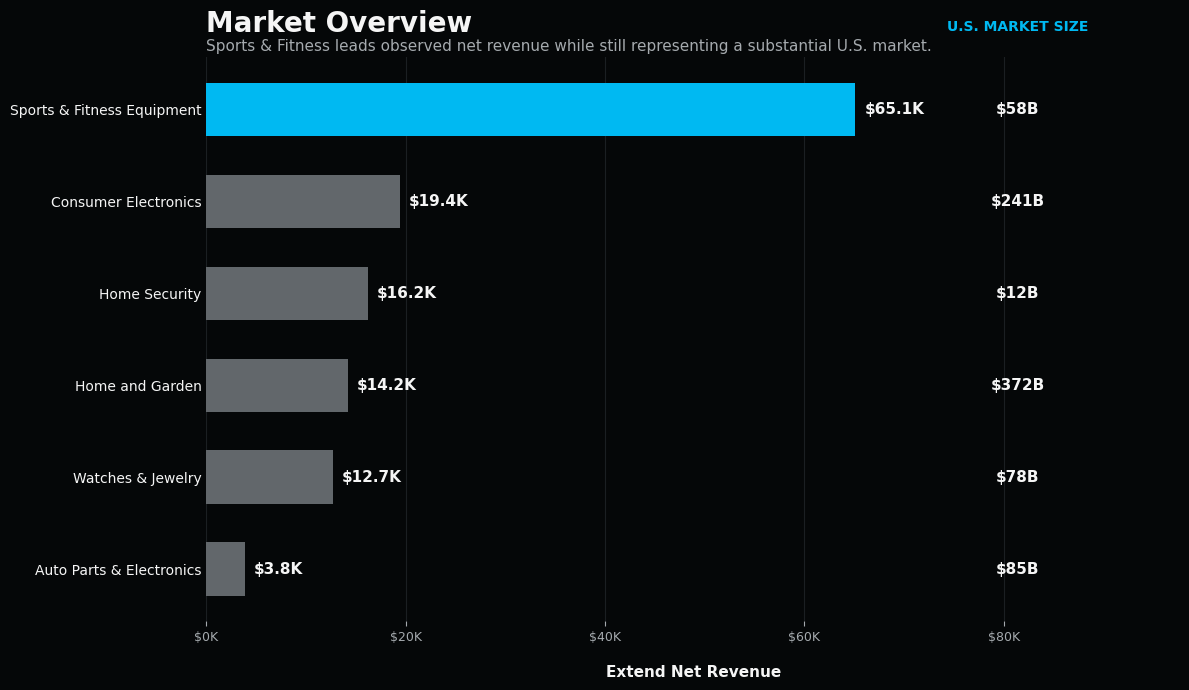

In [157]:
#Create visualization for slides
plot_df = (
    industry_decision
    .sort_values("net_revenue", ascending=True)
    .copy()
)

#Extend-style colors
background = "#050708"
cyan = "#00B9F2"
grey = "#62676B"
white = "#F5F5F5"
muted = "#A5AAAE"
grid = "#252A2E"

colors = [
    cyan if industry == "Sports & Fitness Equipment"
    else grey
    for industry in plot_df["storetype"]
]

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor(background)
ax.set_facecolor(background)

#create bar plot
bars = ax.barh(
    plot_df["storetype"],
    plot_df["net_revenue"],
    color=colors,
    height=0.58
)

#add net revenue labels
for bar, revenue in zip(
    bars,
    plot_df["net_revenue"]
):
    ax.text(
        bar.get_width() + 900,
        bar.get_y() + bar.get_height() / 2,
        f"${revenue/1000:.1f}K",
        va="center",
        color=white,
        fontsize=11,
        fontweight="bold"
    )

#style chart
#give room for both labels
max_revenue = plot_df["net_revenue"].max()

ax.set_xlim(0, max_revenue * 1.50)

market_label_x = max_revenue * 1.25

#column header
ax.text(
    market_label_x,
    len(plot_df) - 0.15,
    "U.S. MARKET SIZE",
    color=cyan,
    fontsize=10,
    fontweight="bold",
    ha="center"
)

#market size values
for bar, market_size in zip(
    bars,
    plot_df["market_size"]
):
    ax.text(
        market_label_x,
        bar.get_y() + bar.get_height() / 2,
        f"${market_size:.0f}B",
        va="center",
        ha="center",
        color=white,
        fontsize=11,
        fontweight="bold"
    )

ax.set_xlabel(
    "Extend Net Revenue",
    color=white,
    fontsize=11,
    fontweight="bold",
    labelpad=15
)

ax.set_title(
    "Market Overview",
    color=white,
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=18
)

# Subtitle
ax.text(
    0,
    1.01,
    "Sports & Fitness leads observed net revenue while still representing a substantial U.S. market.",
    transform=ax.transAxes,
    color=muted,
    fontsize=11
)

# Y-axis labels
ax.tick_params(
    axis="y",
    colors=white,
    labelsize=10,
    length=0
)

# X-axis
ax.tick_params(
    axis="x",
    colors=muted,
    labelsize=9
)

# Format x-axis as $K
ticks = ax.get_xticks()
ax.set_xticklabels(
    [f"${x/1000:.0f}K" for x in ticks]
)

# Subtle grid
ax.xaxis.grid(
    True,
    color=grid,
    linewidth=0.8,
    alpha=0.7
)

ax.set_axisbelow(True)

# Remove unnecessary borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

##Recommendation

Sports & Fitness Equipment is the strongest Business Development opportunity. It has the strongest market fit for warrant attachment and Extend revenue. It leads all industries in attach rate for both units (9.57%) and dollars (1.52%) and greatly exceeds the other industries in net revenue. The Sports & Fitness market is very large at about 58B in the US and expected to grow over time.

# Additional Analysis

##What is drving the overall decline in attach rate?

Unit attach rate decreases over the 3 month period from 9.09% to 6.34%. Dollar attach rate decreases from 1.34% to 0.84% in the same period. Understanding and fixing the decliine would be a huge revenue oppotunity for Extend.

I would want to determine whether the decline is due to merchant/product mix or declining performance within existing merchants. I would explore offer impressions, product attributes, merchant onboarding dates, checkout placement, and device. This would give a better view of what is driving warranty purchases. I would segment by these dimensions to specify why the decline is occuring. This would allow us to design A/B tests or regression experiments to determine whether changes can improve attachment.


## What explains the large differences in attach rate among merchants in the same industry?

The Consumer Electronics industry ranges from 3.7% to 15.1% attach rate and Sports & Fitness Equipment ranges from 6.5% to 17.7%. Merchants in these industries are finding success while others are lagging behind. I would want to identify the merchant or product factors that help explain why some merchants are outperforming others in the same industry.

I would explore product category, warranty to product price ratio, offer placement, and device/channel. I'd perform segmented analysis and regression to quantify attach rate drivers for the high performing merchant/product combinations. Then I would want to design targeted A/B tests to see if those strategies can be replicated for under performing merchants.

# Conclusion

##Questions w/ Answers
1. Please review the integrity of the data. Do you notice any data anomalies or
idiosyncrasies? If so, please describe them.
    
    **A:**  
    * In orders, source_name has 6 different app_id values for 'web'. Also, several records populate source_name with the numeric app_id rather than a descriptive source label. This affects our ability to accurately segment by source.
        * I imputed numeric values with 'unknown' except 580111 which matched 79K web app_id. 1354745 had matches in both shopify draft order and web. Since there was not enough evidence to support imputing either case, I also kept this as unknown.
    * There were about 7K missing is_warrantable records. After exploring these records, there was not enough evidence to support imputing with False or True.
        * Since this directly impacts attach rate analysis, I kept these records as null and calculated attach rate using only products marked as is_warrantable=True.
    * Orders and Order_lines had extreme outliers and results with zero price/discount. The extreme outliers are connected all to a luxury watch store so these are accurate. The zero price/discount results appear consistent with valid orders. There is no need to remove these from analysis.
    * I identified multiple contracts associated with the same line item_id. Most of these are legitimate because order lines contain multiple unites. A subset had more contracts than purchased units.
        * I identified contracts identical across all columns with different contract ids. I removed the excess records from the subset with more contracts than purchased units.
    * All orders for the 3 RefurbPCLand results are attributed to the non-approved sortkey created in March 2020. This indicates merchant status is not aligned with transaction activity.
        * I treated the transactional sortkey as the source of truth for order and contract analysis and didn't use approved as a filter.
    * Contracts has products where the warranty was sold but in orderlines, it is marked as not warrantable.
        * I calculated attach rate by joining contracts and orderlines and taking the is_warrantable value count from there.


2. Calculate attach rate overall and by merchant per month on a unit and dollar basis.

    **A:**  
    * **Overall Unit Attach Rate:** 7.18%
    * **Overall Dollar Attach Rate:** 0.93%
    * **Overall Unit Attach Rate by Month:**
        * Mar 2020: 9.09%
        * Apr 2020: 8.22%
        * May 2020: 6.34%
    * **Overall Dollar Attach Rate by Month:**
        * Mar 2020: 1.34%
        * Apr 2020: 0.97%
        * May 2020: 0.84%

    * **Top 3 Unit Attach Rate by Merchant:**
        * ElectricSkatePark: 17.68%
        * RefurbPCLand: 15.13%
        * SecurityCamDirect: 14.29%
    * **Top 3 Dollar Attach Rate by Merchant:**
        * ElectricSkatePark: 2.81%
        * SecurityCamDirect: 2.71%
        * RefurbPCLand: 2.22%
    * **Top Unit Attach Rate by Merchant by Month:**
        * March 2020: SecurityCamDirect, 17.61%
        * April 2020: RefurbPCLand, 42.68%
        * May 2020: ElectricSkatePark, 20.00%
    * **Top Dollar Attach Rate by Merchant by Month:**
        * March 2020: SecurityCamDirect, 3.06%
        * April 2020: RefurbPCLand, 6.40%
        * May 2020: ElectricSkatePark, 3.16%

3. Which merchant industry would you focus business development on based on current attach rate and your views on market sizing?

        Assume we have roughly the same market penetration in each industry so that saturation is not a concern and assume net revenue to Extend is calculated by warranty sales * (1-merchant cut).
        Please put together a 2 or 3 page PowerPoint (or Google Slides) presentation to the Extend executive team with your recommendation.

    **A:**
    
    I would recommend focusing business development in the Sports & Fitness Equipment industry. It has the strongest market fit for warrant attachment and Extend revenue. It leads all industries in attach rate for both unit (9.57%) and dollar (1.52%) values and more than $65K in observed net revenue, exceeding other industries by more than 3x. The Sports & Fitness market is very large at about 58B in the US and expected to grow over time.  

4. After exploring the data, define at least two questions you would be interested in
exploring. Include 1 additional slide at the end of your PowerPoint presentation as “Next
Steps” and at a minimum, supply:

        a. What the question is and why it matters for the business.
        b. What in the current data you have assembled makes you interested in the question.
        c. What additional data would you want to explore the question.
        d. At a high level, what you would do with the data to answer the question.

    **A:**  
    **1. What is drving the overall decline in attach rate?**
    
    Why it matters:
    
    Unit attach rate decreases over the 3 month period from 9.09% to 6.34%. Dollar attach rate decreases from 1.34% to 0.84% in the same period. Understanding and fixing the decline would be a huge revenue oppotunity for Extend.

    What additional data is needed:
    
    I would want to determine whether the decline is due to merchant/product mix or declining performance within existing merchants. I would explore offer impressions, product attributes, merchant onboarding dates, checkout placement, and device. This would give a better view of what is driving warranty purchases.
    
    What would I do with the data:
    
    I would segment by these dimensions to specify why the decline is occuring. This would allow us to design A/B tests or regression experiments to determine whether changes can improve attachment.

    **2. What explains the large differences in attach rate among merchants in the same industry?**
    
    Why it matters:
    
    The Consumer Electronics industry ranges from 3.7% to 15.1% attach rate and Sports & Fitness Equipment ranges from 6.5% to 17.7%. Merchants in these industries are finding success while others are lagging behind. I would want to identify the merchant or product factors that explain why some merchants are outperforming others in the same industry.

    What additional data is needed:
    
    I would explore product category, warranty to product price ratio, offer placement, and device/channel.
    
    What would I do with the data:
    
    I'd perform segmented analysis and regression to quantify attach rate drivers for the high performing merchant/product combinations. Then I would design targeted A/B tests to evaluate if those strategies can be replicated for under performing merchants.


5. Please send a Jupyter/Rstudio notebook with your work and the files you utilized for
completing the exercise.


6. Please share any feedback you have on the exercise and how we can make it better!

    **A:**
    *  In the data overview it says "Check it out at a merchant like August to get a sense of the data." but there is no merchant named August.
    * Data dictionary doesn't include app_id or source_name in the orders table